# Exploratory Data Analysis

#### Reading dataset

In [130]:
import pandas as pd
#Load the data
df = pd.read_csv("C:/Users/35192/Desktop/AnaliseDadosSaude/PROJETO2ANALISE_DADOS_SAUDE/archive/Healthcare Workforce Mental Health Dataset.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Employee ID             5000 non-null   object
 1   Employee Type           5000 non-null   object
 2   Department              5000 non-null   object
 3   Workplace Factor        5000 non-null   object
 4   Stress Level            5000 non-null   int64 
 5   Burnout Frequency       5000 non-null   object
 6   Job Satisfaction        5000 non-null   int64 
 7   Access to EAPs          5000 non-null   object
 8   Mental Health Absences  5000 non-null   int64 
 9   Turnover Intention      5000 non-null   object
dtypes: int64(3), object(7)
memory usage: 390.8+ KB


#### Missing values, Variables type, type of categories

In [118]:
import pandas as pd

def analisar_categorias(dataframe):
    
    resultado = {}
    
    for coluna in dataframe.columns:
        print(f"\n{'='*60}")
        print(f"Variable: {coluna}")
        print(f"Type of data: {dataframe[coluna].dtype}")
        
        # Número de valores únicos
        n_unicos = dataframe[coluna].nunique()
        print(f"Number of unique values: {n_unicos}")
        
        # If Categoric
        if dataframe[coluna].dtype == 'object' or n_unicos < 20:
            
            resultado[coluna] = {
                'tipo': 'categórica' if dataframe[coluna].dtype == 'object' else 'numérica discreta',
                'categorias': dataframe[coluna].unique().tolist(),
                'n_unicos': n_unicos
            }
        else:
            # If Numeric
            print("\nStatistics:")
            print(dataframe[coluna].describe().to_string())
            
            resultado[coluna] = {
                'tipo': 'numérica contínua',
                'min': dataframe[coluna].min(),
                'max': dataframe[coluna].max(),
                'media': dataframe[coluna].mean(),
                'n_unicos': n_unicos
            }
    
    #  Checar Employee ID duplicados
    if 'Employee ID' in dataframe.columns:
        print(f"\n{'='*60}")
        print("Verification of duplicate Employee ID:")
        duplicados = dataframe[dataframe.duplicated(subset=['Employee ID'], keep=False)]
        n_duplicados = duplicados.shape[0]
        if n_duplicados > 0:
            print(f"Encontrados {n_duplicados} registros duplicados de Employee ID:")
            print(duplicados[['Employee ID']].drop_duplicates().to_string(index=False))
        else:
            print("Not found  duplicate Employee ID.")
    
    return resultado

info_vars = analisar_categorias(df)

# Overview
print("\n\n" + "="*60)
print(" DATASET OVERVIEW")
print("="*60)

resumo = pd.DataFrame({
    'Data_Type': df.dtypes,
    'Unique_Value': df.nunique(),
    'Sample_Levels': [df[col].unique()[:5] if df[col].nunique() > 5 
                         else df[col].unique() for col in df.columns]
})
print(resumo.to_string())



Variable: Employee ID
Type of data: object
Number of unique values: 5000

Variable: Employee Type
Type of data: object
Number of unique values: 10

Variable: Department
Type of data: object
Number of unique values: 10

Variable: Workplace Factor
Type of data: object
Number of unique values: 8

Variable: Stress Level
Type of data: int64
Number of unique values: 6

Variable: Burnout Frequency
Type of data: object
Number of unique values: 3

Variable: Job Satisfaction
Type of data: int64
Number of unique values: 5

Variable: Access to EAPs
Type of data: object
Number of unique values: 2

Variable: Mental Health Absences
Type of data: int64
Number of unique values: 20

Statistics:
count    5000.000000
mean        7.396200
std         2.878625
min         0.000000
25%         5.000000
50%         7.000000
75%         9.000000
max        19.000000

Variable: Turnover Intention
Type of data: object
Number of unique values: 2

Verification of duplicate Employee ID:
Not found  duplicate Employ

In [120]:
#df.head()
df.isnull().sum()


Employee ID               0
Employee Type             0
Department                0
Workplace Factor          0
Stress Level              0
Burnout Frequency         0
Job Satisfaction          0
Access to EAPs            0
Mental Health Absences    0
Turnover Intention        0
dtype: int64

In [122]:
df.describe()

,Stress Level,Job Satisfaction,Mental Health Absences
count,5000.000000,5000.000000,5000.000000
mean,7.327800,2.202200,7.396200
std,1.407673,1.045722,2.878625
min,4.000000,1.000000,0.000000
25%,7.000000,1.000000,5.000000
50%,8.000000,2.000000,7.000000
75%,8.000000,3.000000,9.000000
max,9.000000,5.000000,19.000000


In [124]:
df.describe(include='object')

,Employee ID,Employee Type,Department,Workplace Factor,Burnout Frequency,Access to EAPs,Turnover Intention
count,5000,5000,5000,5000,5000,5000,5000
unique,5000,10,10,8,3,2,2
top,HCP-00001,Registered Nurse,General Medicine,Heavy Workload,Often,Yes,Yes
freq,1,1283,1283,2138,2221,3594,3335


#### Distributions & Plots 

###### Categoric Variables

In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.pyplot as plt
import numpy as np

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10
plt.rcParams['font.family'] = 'Times New Roman'         

def analisar_variaveis_categoricas(df, variaveis=None, tipo='ambas', ordenar_por='frequencia'):
     
    if variaveis is None:
        variaveis = df.select_dtypes(include=['object', 'category']).columns.tolist()
    
    resultados = {}
    
    for var in variaveis:
        if var not in df.columns:
            print(f"Aviso: Variável '{var}' não encontrada no dataset")
            continue
        
        freq_abs = df[var].value_counts(dropna=False)
        
        freq_rel = df[var].value_counts(normalize=True, dropna=False) * 100
        
        if tipo == 'absoluta':
            resultado = pd.DataFrame({
                'Frequência Absoluta': freq_abs
            })
        elif tipo == 'relativa':
            resultado = pd.DataFrame({
                'Frequência Relativa (%)': freq_rel.round(2)
            })
        else: 
            resultado = pd.DataFrame({
                'Frequência Absoluta': freq_abs,
                'Frequência Relativa (%)': freq_rel.round(2)
            })
        
        if ordenar_por == 'frequencia':
            resultado = resultado.sort_values(by=resultado.columns[0], ascending=False)
        elif ordenar_por == 'categoria':
            resultado = resultado.sort_index()
        
        resultados[var] = resultado
    
    return resultados


def exibir_frequencias(resultados, mostrar_total=True):
    
    for var, df_freq in resultados.items():
        print(f"\n{'='*60}")
        print(f"VARIÁVEL: {var}")
        print(f"{'='*60}")
        print(df_freq)
        
        if mostrar_total:
            print(f"{'-'*60}")
            if 'Frequência Absoluta' in df_freq.columns:
                total = df_freq['Frequência Absoluta'].sum()
                print(f"Total: {total}")


def plotar_frequencias(resultados, tipo_freq='absoluta', figsize=(12, 8), cores='viridis', salvar=True, pasta='graficos_frequencias'):
     
    if salvar:
        os.makedirs(pasta, exist_ok=True)
    
    sns.set_style("whitegrid")
    plt.rcParams['font.size'] = 20

    column = 'Frequência Absoluta' if tipo_freq == 'absoluta' else 'Frequência Relativa (%)'

    for var, df_freq in resultados.items():
        if column not in df_freq.columns:
            print(f" Warning: Column '{column}' not found for '{var}'")
            continue

        categories = df_freq.index.astype(str)
        values = df_freq[column]

        palette = sns.color_palette(cores, len(categories)) if isinstance(cores, str) else cores
        fig, ax = plt.subplots(figsize=figsize)

        bars = ax.bar(range(len(categories)), values, color=palette, edgecolor='black', linewidth=1.2)

        for bar, value in zip(bars, values):
            text = f'{value:.1f}%' if tipo_freq == 'relativa' else f'{int(value)}'
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                    text, ha='center', va='bottom', fontweight='bold', fontsize=15)

        ax.set_xlabel('Categories', fontsize=20, fontweight='bold')
        ylabel = 'Absolute Frequency' if tipo_freq == 'absoluta' else 'Relative Frequency (%)'
        ax.set_ylabel(ylabel, fontsize=20, fontweight='bold')
        ax.set_title(f'Frequency Distribution - {var}', fontsize=30, fontweight='bold', pad=15)
        ax.set_xticks(range(len(categories)))
        ax.set_xticklabels(categories, rotation=40, ha='right', fontsize=20)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.set_axisbelow(True)
        ax.set_ylim(0, values.max() * 1.2)

        plt.tight_layout()

        if salvar:
            nome_arquivo = f"{var.replace(' ', '_')}_{tipo_freq}.png"
            caminho = os.path.join(pasta, nome_arquivo)
            plt.savefig(caminho, dpi=300, bbox_inches='tight')
            print(f" Saved: {caminho}")

        plt.close(fig)  

def analise_completa(df, variaveis=None, tipo='ambas', mostrar_graficos=True, 
                     tipo_grafico='absoluta', cores='viridis'):
    
    resultados = analisar_variaveis_categoricas(df, variaveis, tipo)
    
    exibir_frequencias(resultados)
    
    if mostrar_graficos:
        plotar_frequencias(resultados, tipo_freq=tipo_grafico, cores=cores)
    
    return resultados

In [134]:
analise_completa(df, variaveis=['Burnout Frequency' ], tipo_grafico='relativa')
analise_completa(df, variaveis=['Access to EAPs' ], tipo_grafico='relativa')
analise_completa(df, variaveis=['Turnover Intention' ], tipo_grafico='relativa')
analise_completa(df, variaveis=['Employee Type' ], tipo_grafico='relativa')
analise_completa(df, variaveis=['Department' ], tipo_grafico='relativa')
analise_completa(df, variaveis=['Workplace Factor' ], tipo_grafico='relativa')
analise_completa(df, variaveis=['Mental Health Absences' ], tipo_grafico='relativa')
analise_completa(df, variaveis=['Job Satisfaction' ], tipo_grafico='relativa')
analise_completa(df, variaveis=['Stress Level' ], tipo_grafico='relativa')
analise_completa(df, variaveis=['Turnover Intention' ], tipo_grafico='relativa')


VARIÁVEL: Burnout Frequency
                   Frequência Absoluta  Frequência Relativa (%)
Burnout Frequency                                              
Often                             2221                    44.42
Occasionally                      1941                    38.82
Never                              838                    16.76
------------------------------------------------------------
Total: 5000
 Saved: graficos_frequencias\Burnout_Frequency_relativa.png

VARIÁVEL: Access to EAPs
                Frequência Absoluta  Frequência Relativa (%)
Access to EAPs                                              
Yes                            3594                    71.88
No                             1406                    28.12
------------------------------------------------------------
Total: 5000
 Saved: graficos_frequencias\Access_to_EAPs_relativa.png

VARIÁVEL: Turnover Intention
                    Frequência Absoluta  Frequência Relativa (%)
Turnover Intention     

{'Turnover Intention':                     Frequência Absoluta  Frequência Relativa (%)
 Turnover Intention                                              
 Yes                                3335                     66.7
 No                                 1665                     33.3}

###### Numeric Variables

In [136]:
import matplotlib.ticker as mticker
import seaborn as sns
import matplotlib.pyplot as plt
import os

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 15

def plot_numerical_variables(df, pasta='numerical_graphs', cores='viridis', salvar=True):
    """
    Generate and save plots for numerical variables related to mental health and turnover.
    """

    if salvar:
        os.makedirs(pasta, exist_ok=True)

    # -------------------------------------------------------
    # 1. Boxplot – Stress Level by Turnover Intention
    # -------------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.boxplot(
        data=df,
        x='Turnover Intention',
        y='Stress Level',
        palette=cores,
        width=0.6,
        linewidth=1.2,
        ax=ax
    )

    ax.set_title('Boxplot of Stress Level by Turnover Intention', fontsize=30, fontweight='bold', pad=15)
    ax.set_xlabel('Turnover Intention', fontsize=20, fontweight='bold')
    ax.set_ylabel('Stress Level', fontsize=20, fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()

    if salvar:
        nome_arquivo = os.path.join(pasta, 'Boxplot_Stress_Level_by_Turnover_Intention.png')
        plt.savefig(nome_arquivo, dpi=300, bbox_inches='tight')
        print(f" Saved: {nome_arquivo}")
    plt.close(fig)

    # -------------------------------------------------------
    # 2. Boxplot – Job Satisfaction by Turnover Intention
    # -------------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.boxplot(
        data=df,
        x='Turnover Intention',
        y='Job Satisfaction',
        palette=cores,
        width=0.6,
        linewidth=1.2,
        ax=ax
    )

    ax.set_title('Boxplot of Job Satisfaction by Turnover Intention', fontsize=30, fontweight='bold', pad=15)
    ax.set_xlabel('Turnover Intention', fontsize=20, fontweight='bold')
    ax.set_ylabel('Job Satisfaction', fontsize=20, fontweight='bold')
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()

    if salvar:
        nome_arquivo = os.path.join(pasta, 'Boxplot_Job_Satisfaction_by_Turnover_Intention.png')
        plt.savefig(nome_arquivo, dpi=300, bbox_inches='tight')
        print(f" Saved: {nome_arquivo}")
    plt.close(fig)

    #-------------------------------------------------------
   # 3. Histogram – Mental Health Absences
    #-------------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.histplot(
        data=df,
        x='Mental Health Absences',
        bins=20,
        kde=True,
        color=sns.color_palette(cores)[3],
        edgecolor='black',
        ax=ax
    )

    ax.set_title('Distribution of Mental Health Absences', fontsize=30, fontweight='bold', pad=15)
    ax.set_xlabel('Number of Absences (Mental Health)', fontsize=20, fontweight='bold')
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.set_ylabel('Frequency', fontsize=20, fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()

    if salvar:
        nome_arquivo = os.path.join(pasta, 'Histogram_Mental_Health_Absences.png')
        plt.savefig(nome_arquivo, dpi=300, bbox_inches='tight')
        print(f" Saved: {nome_arquivo}")
    plt.close(fig)

    ###########################################

    fig, ax = plt.subplots(figsize=(10,6))
    sns.boxplot(
        data=df,
        x='Turnover Intention',
        y='Mental Health Absences',
        palette=cores,
        width=0.6,
        linewidth=1.2,
        ax=ax
    )

    ax.set_title('Boxplot of Mental Health Absences by Turnover Intention', fontsize=30, fontweight='bold', pad=15)
    ax.set_xlabel('Turnover Intention', fontsize=20, fontweight='bold')
    ax.set_ylabel('Mental Health Absences', fontsize=20, fontweight='bold')
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()

    if salvar:
        nome_arquivo = os.path.join(pasta, 'Boxplot_Mental_Health_Absences_by_Turnover_Intention.png')
        plt.savefig(nome_arquivo, dpi=300, bbox_inches='tight')
        print(f" Saved: {nome_arquivo}")
    plt.close(fig)

In [138]:
plot_numerical_variables(df)

C:\Users\35192\AppData\Local\Temp\ipykernel_13872\3713744931.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


 Saved: numerical_graphs\Boxplot_Stress_Level_by_Turnover_Intention.png


C:\Users\35192\AppData\Local\Temp\ipykernel_13872\3713744931.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


 Saved: numerical_graphs\Boxplot_Job_Satisfaction_by_Turnover_Intention.png
 Saved: numerical_graphs\Histogram_Mental_Health_Absences.png


C:\Users\35192\AppData\Local\Temp\ipykernel_13872\3713744931.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


 Saved: numerical_graphs\Boxplot_Mental_Health_Absences_by_Turnover_Intention.png


In [140]:
# NUMERICAL VARIABLE – BOXPLOT + MANN-WHITNEY U TEST
#Mental Health Absences has a lot of outliers. We did this test to very difference between groups

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import mannwhitneyu
import os

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 15

def plot_numerical_with_mannwhitney(df, variable='Mental Health Absences',
                                    group='Turnover Intention',
                                    pasta='numerical_graphs',
                                    cores='viridis', salvar=True):

    if salvar:
        os.makedirs(pasta, exist_ok=True)

    # ---- Mann-Whitney U Test ----
    group_no = df[df[group] == 'No'][variable].dropna()
    group_yes = df[df[group] == 'Yes'][variable].dropna()
    stat, p = mannwhitneyu(group_no, group_yes, alternative='two-sided')

    print(f"Mann-Whitney U test for {variable} by {group}:")
    print(f"U statistic = {stat:.3f}, p-value = {p:.5f}")
    print("Significant difference between groups!" if p < 0.05 else "No significant difference between groups.")

    # ---- Boxplot ----
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.boxplot(
        data=df,
        x=group,
        y=variable,
        palette=cores,
        width=0.6,
        linewidth=1.2,
        ax=ax
    )

    ax.set_title(f'Boxplot of {variable} by {group}', fontsize=25, fontweight='bold', pad=15)
    ax.set_xlabel(group, fontsize=18, fontweight='bold')
    ax.set_ylabel(variable, fontsize=18, fontweight='bold')
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()

    if salvar:
        filename = os.path.join(pasta, f'Boxplot_{variable}_by_{group}.png')
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        print(f"Saved: {filename}")

    plt.close(fig)

In [142]:
plot_numerical_with_mannwhitney(df, variable='Mental Health Absences')

Mann-Whitney U test for Mental Health Absences by Turnover Intention:
U statistic = 2396035.000, p-value = 0.00000
Significant difference between groups!


C:\Users\35192\AppData\Local\Temp\ipykernel_13872\3876428565.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Saved: numerical_graphs\Boxplot_Mental Health Absences_by_Turnover Intention.png


In [144]:
# BOXPLOT + MANN-WHITNEY + EFFECT SIZE
# Here we measured how different they are
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import mannwhitneyu
import os

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 15

def plot_numerical_with_mannwhitney(df, variable='Mental Health Absences',
                                    group='Turnover Intention',
                                    pasta='numerical_graphs',
                                    cores='viridis', salvar=True):
    """
    Creates a boxplot and performs a Mann-Whitney U test with effect size.
    """
    # Create folder if needed
    if salvar:
        os.makedirs(pasta, exist_ok=True)
    
    # ---- Prepare data ----
    group_no = df[df[group] == 'No'][variable].dropna()
    group_yes = df[df[group] == 'Yes'][variable].dropna()
    
    n1 = len(group_yes)
    n2 = len(group_no)
    
    # ---- Mann-Whitney U Test ----
    stat, p = mannwhitneyu(group_no, group_yes, alternative='two-sided')
    
    # ---- Calculate Effect Size (Rank-Biserial Correlation) ----
    rank_biserial = 1 - (2 * stat) / (n1 * n2)
    
    # Interpret magnitude
    abs_r = abs(rank_biserial)
    if abs_r < 0.1:
        magnitude = "Negligível"
    elif abs_r < 0.3:
        magnitude = "Pequeno"
    elif abs_r < 0.5:
        magnitude = "Médio"
    else:
        magnitude = "Grande"
    
    # ---- Print Results ----
    print(f"\nMann-Whitney U test for {variable} by {group}:")
    print(f"U statistic = {stat:.10f}, p-value = {p:.10f}")
    print(f"Effect Size (r) = {rank_biserial:.3f} ({magnitude})")
    print("Significant difference!" if p < 0.05 else "No significant difference.")
    
    # ---- Boxplot ----
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.boxplot(
        data=df,
        x=group,
        y=variable,
        palette=cores,
        width=0.6,
        linewidth=1.2,
        ax=ax
    )
    ax.set_title(f'Boxplot of {variable} by {group}', fontsize=25, fontweight='bold', pad=15)
    ax.set_xlabel(group, fontsize=18, fontweight='bold')
    ax.set_ylabel(variable, fontsize=18, fontweight='bold')
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    
    if salvar:
        filename = os.path.join(pasta, f'Boxplot_{variable}_by_{group}.png')
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        print(f"Saved: {filename}")
    
    plt.close(fig)

In [146]:
plot_numerical_with_mannwhitney(df, variable='Mental Health Absences')


Mann-Whitney U test for Mental Health Absences by Turnover Intention:
U statistic = 2396035.0000000000, p-value = 0.0000000000
Effect Size (r) = 0.137 (Pequeno)
Significant difference!


C:\Users\35192\AppData\Local\Temp\ipykernel_13872\4088165978.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Saved: numerical_graphs\Boxplot_Mental Health Absences_by_Turnover Intention.png


###### Job Satisfaction Outliers

In [148]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 15

def analisar_outliers_job_satisfaction(df):
    """
    Identifica e mostra outliers de Job Satisfaction por Turnover Intention
    e retorna um DataFrame com todos os outliers (sem colunas extras).
    """
    outliers_info = {}
    all_outliers = []  

    for grupo in ['No', 'Yes']:
        dados_grupo = df[df['Turnover Intention'] == grupo]['Job Satisfaction']

        Q1 = dados_grupo.quantile(0.25)
        Q3 = dados_grupo.quantile(0.75)
        IQR = Q3 - Q1

        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR

        outliers = df[
            (df['Turnover Intention'] == grupo) &
            ((df['Job Satisfaction'] < limite_inferior) |
             (df['Job Satisfaction'] > limite_superior))
        ]

        all_outliers.append(outliers)

        outliers_info[grupo] = {
            'outliers': outliers,
            'Q1': Q1,
            'Q3': Q3,
            'IQR': IQR,
            'limite_inferior': limite_inferior,
            'limite_superior': limite_superior,
            'num_outliers': len(outliers)
        }

    df_outliers = pd.concat(all_outliers).reset_index(drop=True)

    for grupo, info in outliers_info.items():
        print(f"\n{'='*60}")
        print(f"TURNOVER INTENTION: {grupo}")
        print(f"{'='*60}")
        print(f"Q1: {info['Q1']:.2f}")
        print(f"Q3: {info['Q3']:.2f}")
        print(f"IQR: {info['IQR']:.2f}")
        print(f"Limite Inferior: {info['limite_inferior']:.2f}")
        print(f"Limite Superior: {info['limite_superior']:.2f}")
        print(f"\nNúmero de outliers: {info['num_outliers']}")

        if info['num_outliers'] > 0:
            print(f"\nLinhas dos outliers:")
            print(info['outliers'].to_string(index=False))
        else:
            print("Nenhum outlier encontrado.")

    return outliers_info, df_outliers

In [150]:
#Outliers 
outliers_info, df_outliers = analisar_outliers_job_satisfaction(df)
df_outliers


TURNOVER INTENTION: No
Q1: 2.00
Q3: 4.00
IQR: 2.00
Limite Inferior: -1.00
Limite Superior: 7.00

Número de outliers: 0
Nenhum outlier encontrado.

TURNOVER INTENTION: Yes
Q1: 1.00
Q3: 2.00
IQR: 1.00
Limite Inferior: -0.50
Limite Superior: 3.50

Número de outliers: 254

Linhas dos outliers:
Employee ID            Employee Type          Department         Workplace Factor  Stress Level Burnout Frequency  Job Satisfaction Access to EAPs  Mental Health Absences Turnover Intention
  HCP-00007         Registered Nurse    General Medicine    Poor Work Environment             6      Occasionally                 4            Yes                       3                Yes
  HCP-00059         Registered Nurse    General Medicine           Heavy Workload             8      Occasionally                 4            Yes                       7                Yes
  HCP-00065      Critical Care Nurse                 ICU    Poor Work Environment             6             Never                 5       

,Employee ID,Employee Type,Department,Workplace Factor,Stress Level,Burnout Frequency,Job Satisfaction,Access to EAPs,Mental Health Absences,Turnover Intention
0,HCP-00007,Registered Nurse,General Medicine,Poor Work Environment,6,Occasionally,4,Yes,3,Yes
1,HCP-00059,Registered Nurse,General Medicine,Heavy Workload,8,Occasionally,4,Yes,7,Yes
2,HCP-00065,Critical Care Nurse,ICU,Poor Work Environment,6,Never,5,Yes,7,Yes
3,HCP-00093,Healthcare Administrator,Administration,Job Insecurity,5,Occasionally,4,Yes,4,Yes
4,HCP-00107,Physician (General),General Practice,Heavy Workload,8,Never,4,Yes,5,Yes
...,...,...,...,...,...,...,...,...,...,...
249,HCP-04919,Healthcare Administrator,Administration,Career Stagnation,5,Occasionally,4,Yes,10,Yes
250,HCP-04931,Physician (General),General Practice,Unclear Job Expectations,4,Never,4,Yes,2,Yes
251,HCP-04950,Healthcare Administrator,Administration,Career Stagnation,4,Occasionally,4,Yes,5,Yes
252,HCP-04979,Registered Nurse,General Medicine,Unclear Job Expectations,5,Never,4,Yes,7,Yes


In [154]:
#Outliers Plots of categorical variables
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.pyplot as plt
import numpy as np

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10
plt.rcParams['font.family'] = 'Times New Roman'   

def analisar_variaveis_categoricas(df, variaveis=None, tipo='ambas', ordenar_por='frequencia'):
     
    if variaveis is None:
        variaveis = df.select_dtypes(include=['object', 'category']).columns.tolist()
    
    resultados = {}
    
    for var in variaveis:
        if var not in df.columns:
            print(f"Aviso: Variável '{var}' não encontrada no dataset")
            continue

        freq_abs = df[var].value_counts(dropna=False)
        
        freq_rel = df[var].value_counts(normalize=True, dropna=False) * 100
        
        if tipo == 'absoluta':
            resultado = pd.DataFrame({
                'Frequência Absoluta': freq_abs
            })
        elif tipo == 'relativa':
            resultado = pd.DataFrame({
                'Frequência Relativa (%)': freq_rel.round(2)
            })
        else:  
            resultado = pd.DataFrame({
                'Frequência Absoluta': freq_abs,
                'Frequência Relativa (%)': freq_rel.round(2)
            })
        
        if ordenar_por == 'frequencia':
            resultado = resultado.sort_values(by=resultado.columns[0], ascending=False)
        elif ordenar_por == 'categoria':
            resultado = resultado.sort_index()
        
        resultados[var] = resultado
    
    return resultados


def exibir_frequencias(resultados, mostrar_total=True):
 
    for var, df_freq in resultados.items():
        print(f"\n{'='*60}")
        print(f"VARIÁVEL: {var}")
        print(f"{'='*60}")
        print(df_freq)
        
        if mostrar_total:
            print(f"{'-'*60}")
            if 'Frequência Absoluta' in df_freq.columns:
                total = df_freq['Frequência Absoluta'].sum()
                print(f"Total: {total}")


def plotar_frequencias(resultados, tipo_freq='absoluta', figsize=(12, 8), cores='viridis', salvar=True, pasta='graficos_outliers'):

    if salvar:
        os.makedirs(pasta, exist_ok=True)
    
    sns.set_style("whitegrid")
    plt.rcParams['font.size'] = 20

    column = 'Frequência Absoluta' if tipo_freq == 'absoluta' else 'Frequência Relativa (%)'

    for var, df_freq in resultados.items():
        if column not in df_freq.columns:
            print(f" Warning: Column '{column}' not found for '{var}'")
            continue

        categories = df_freq.index.astype(str)
        values = df_freq[column]

        palette = sns.color_palette(cores, len(categories)) if isinstance(cores, str) else cores
        fig, ax = plt.subplots(figsize=figsize)

        bars = ax.bar(range(len(categories)), values, color=palette, edgecolor='black', linewidth=1.2)

        # Adicionar rótulos nos valores
        for bar, value in zip(bars, values):
            text = f'{value:.1f}%' if tipo_freq == 'relativa' else f'{int(value)}'
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                    text, ha='center', va='bottom', fontweight='bold', fontsize=15)

        # Eixos e título
        ax.set_xlabel('Categories', fontsize=20, fontweight='bold')
        ylabel = 'Absolute Frequency' if tipo_freq == 'absoluta' else 'Relative Frequency (%)'
        ax.set_ylabel(ylabel, fontsize=20, fontweight='bold')
        ax.set_title(f'Frequency Distribution - {var}', fontsize=30, fontweight='bold', pad=15)
        ax.set_xticks(range(len(categories)))
        ax.set_xticklabels(categories, rotation=40, ha='right', fontsize=20)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.set_axisbelow(True)
        ax.set_ylim(0, values.max() * 1.2)

        plt.tight_layout()

        # Salvar gráfico
        if salvar:
            nome_arquivo = f"{var.replace(' ', '_')}_{tipo_freq}.png"
            caminho = os.path.join(pasta, nome_arquivo)
            plt.savefig(caminho, dpi=300, bbox_inches='tight')
            print(f" Saved: {caminho}")

        plt.close(fig)  

def analise_completa(df, variaveis=None, tipo='ambas', mostrar_graficos=True, 
                     tipo_grafico='absoluta', cores='viridis'):
  
    resultados = analisar_variaveis_categoricas(df, variaveis, tipo)
    
    exibir_frequencias(resultados)
    
    if mostrar_graficos:
        plotar_frequencias(resultados, tipo_freq=tipo_grafico, cores=cores)
    return resultados

In [156]:
#Outliers Plots of categorical variables
analise_completa(df_outliers, variaveis=['Burnout Frequency' ], tipo_grafico='relativa')
analise_completa(df_outliers, variaveis=['Access to EAPs' ], tipo_grafico='relativa')
analise_completa(df_outliers, variaveis=['Employee Type' ], tipo_grafico='relativa')
analise_completa(df_outliers, variaveis=['Department' ], tipo_grafico='relativa')
analise_completa(df_outliers, variaveis=['Workplace Factor' ], tipo_grafico='relativa')
analise_completa(df_outliers, variaveis=['Turnover Intention' ], tipo_grafico='relativa')


VARIÁVEL: Burnout Frequency
                   Frequência Absoluta  Frequência Relativa (%)
Burnout Frequency                                              
Occasionally                       127                     50.0
Never                              127                     50.0
------------------------------------------------------------
Total: 254
 Saved: graficos_outliers\Burnout_Frequency_relativa.png

VARIÁVEL: Access to EAPs
                Frequência Absoluta  Frequência Relativa (%)
Access to EAPs                                              
Yes                             181                    71.26
No                               73                    28.74
------------------------------------------------------------
Total: 254
 Saved: graficos_outliers\Access_to_EAPs_relativa.png

VARIÁVEL: Employee Type
                          Frequência Absoluta  Frequência Relativa (%)
Employee Type                                                         
Registered Nurse       

{'Turnover Intention':                     Frequência Absoluta  Frequência Relativa (%)
 Turnover Intention                                              
 Yes                                 254                    100.0}

In [166]:
#Outliers Plots of numerical variables

import matplotlib.ticker as mticker
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Global style configuration (same as your previous code)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 15

def plot_numerical_variables(df, pasta='numerical_graphs_outliers', cores='viridis', salvar=True):
    """
    Generate and save plots for numerical variables related to mental health and turnover.
    """

    # Create folder if it does not exist
    if salvar:
        os.makedirs(pasta, exist_ok=True)

    # -------------------------------------------------------
    # 1. Boxplot – Stress Level by Turnover Intention
    # -------------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.boxplot(
        data=df,
        x='Turnover Intention',
        y='Stress Level',
        palette=cores,
        width=0.6,
        linewidth=1.2,
        ax=ax
    )

    ax.set_title('Boxplot of Stress Level by Turnover Intention', fontsize=30, fontweight='bold', pad=15)
    ax.set_xlabel('Turnover Intention', fontsize=20, fontweight='bold')
    ax.set_ylabel('Stress Level', fontsize=20, fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()

    if salvar:
        nome_arquivo = os.path.join(pasta, 'Boxplot_Stress_Level_by_Turnover_Intention.png')
        plt.savefig(nome_arquivo, dpi=300, bbox_inches='tight')
        print(f" Saved: {nome_arquivo}")
    plt.close(fig)

    # -------------------------------------------------------
    # 2. Boxplot – Mental Health Absences
    # -------------------------------------------------------
    
    fig, ax = plt.subplots(figsize=(10,6))
    sns.boxplot(
        data=df,
        x='Turnover Intention',
        y='Mental Health Absences',
        palette=cores,
        width=0.6,
        linewidth=1.2,
        ax=ax
    )

    ax.set_title('Boxplot of Mental Health Absences by Turnover Intention', fontsize=30, fontweight='bold', pad=15)
    ax.set_xlabel('Turnover Intention', fontsize=20, fontweight='bold')
    ax.set_ylabel('Mental Health Absences', fontsize=20, fontweight='bold')
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()

    if salvar:
        nome_arquivo = os.path.join(pasta, 'Boxplot_Mental_Health_Absences_by_Turnover_Intention.png')
        plt.savefig(nome_arquivo, dpi=300, bbox_inches='tight')
        print(f" Saved: {nome_arquivo}")
    plt.close(fig)

In [168]:
#Outliers Plots of numerical variables
plot_numerical_variables(df_outliers)

C:\Users\35192\AppData\Local\Temp\ipykernel_13872\2046381397.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


 Saved: numerical_graphs_outliers\Boxplot_Stress_Level_by_Turnover_Intention.png


C:\Users\35192\AppData\Local\Temp\ipykernel_13872\2046381397.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


 Saved: numerical_graphs_outliers\Boxplot_Mental_Health_Absences_by_Turnover_Intention.png


#### Coding Categorical Variables

In [170]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# LABEL ENCODING
label_cols = ['Burnout Frequency', 'Access to EAPs', 'Turnover Intention']
label_encoders = {}

for col in label_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# ONE-HOT ENCODING
one_hot_cols = ['Employee Type', 'Department', 'Workplace Factor']
df = pd.get_dummies(df, columns=one_hot_cols,dtype=int)

df.drop('Employee ID', axis=1, inplace=True)

df.head()

,Stress Level,Burnout Frequency,Job Satisfaction,Access to EAPs,Mental Health Absences,Turnover Intention,Employee Type_Critical Care Nurse,Employee Type_Healthcare Administrator,Employee Type_Laboratory Technician,Employee Type_Medical Assistant,...,Department_Radiology,Department_Specialty Care,Workplace Factor_Career Stagnation,Workplace Factor_Emotional Demands,Workplace Factor_Heavy Workload,Workplace Factor_Job Insecurity,Workplace Factor_Poor Work Environment,Workplace Factor_Safety Concerns,Workplace Factor_Unclear Job Expectations,Workplace Factor_Work-Life Imbalance
0,8,2,2,1,6,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,8,2,1,1,12,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
2,6,1,2,1,9,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,7,0,4,0,11,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
4,8,1,2,1,7,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


#### Correlations & Feature Selection

 Correlation heatmap saved successfully at: correlation_maps\spearman_correlation_heatmap.png


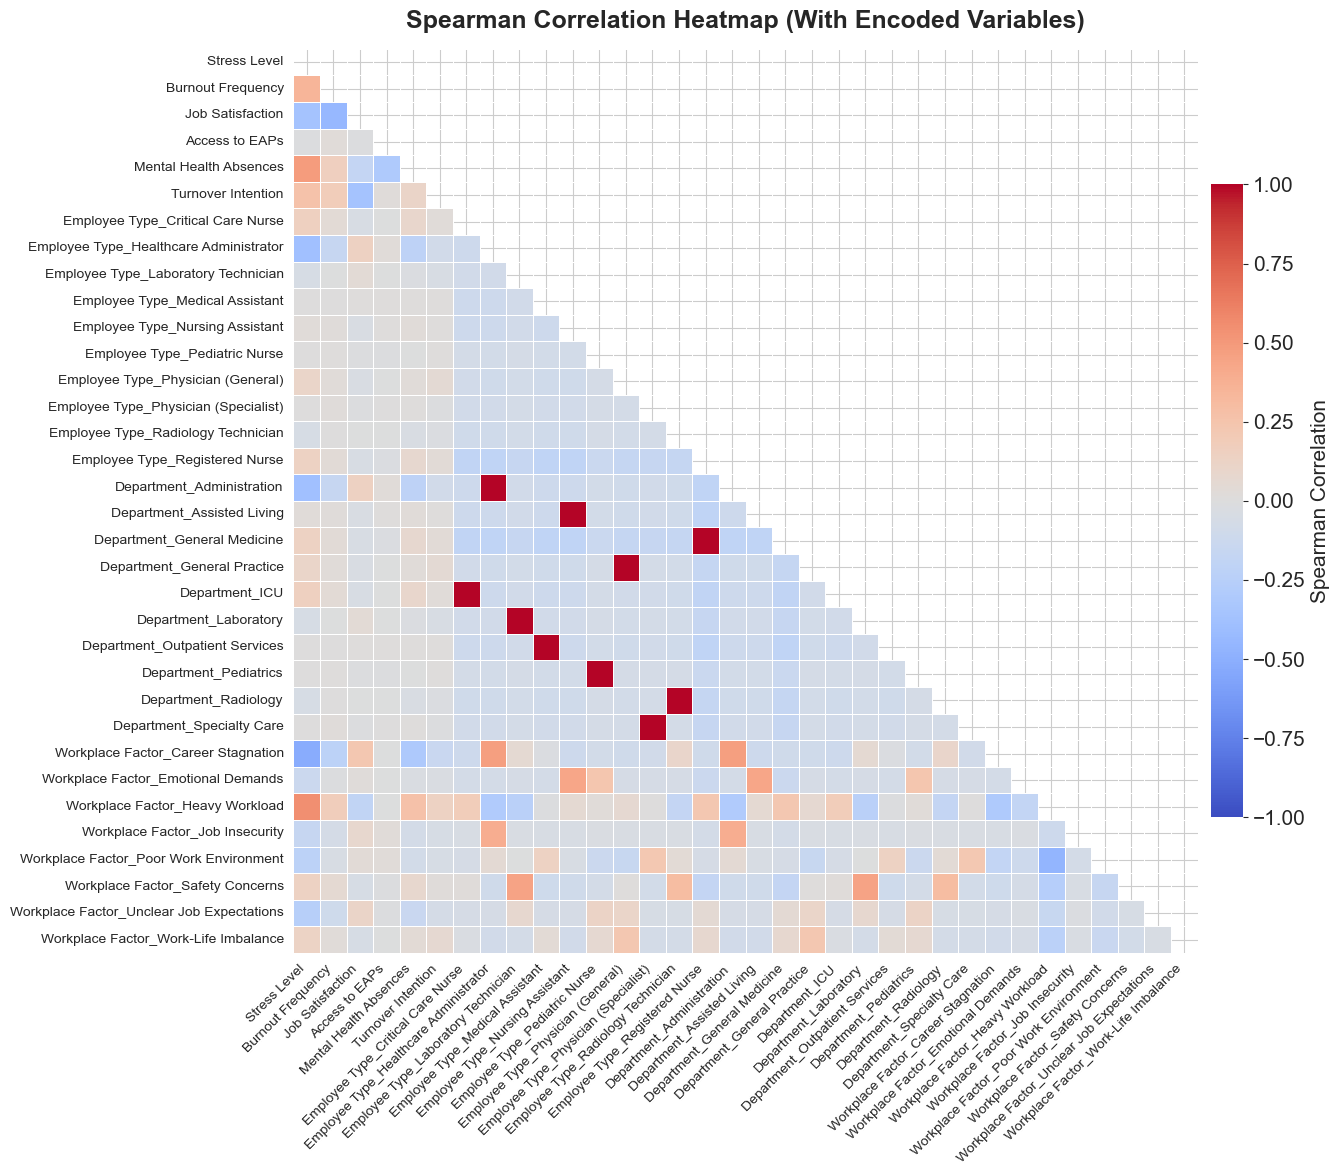

In [172]:
# SPEARMAN CORRELATION HEATMAP 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.rcParams['figure.figsize'] = (16, 12)
plt.rcParams['font.size'] = 15

corr = df.corr(method='spearman', numeric_only=True)

mask = np.triu(np.ones_like(corr, dtype=bool))

output_folder = "correlation_maps"
os.makedirs(output_folder, exist_ok=True)
output_file = os.path.join(output_folder, "spearman_correlation_heatmap.png")

# heatmap 
plt.figure(figsize=(16, 12))
sns.heatmap(
    corr,
    mask=mask,
    cmap='coolwarm',          
    vmin=-1, vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    annot=False,
    cbar_kws={'shrink': 0.7, 'label': 'Spearman Correlation','pad': 0.01 }
)

plt.title("Spearman Correlation Heatmap (With Encoded Variables)", fontsize=18, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()

plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f" Correlation heatmap saved successfully at: {output_file}")

plt.show()

In [174]:
import pandas as pd
import numpy as np

df_num = df.select_dtypes(include=[np.number])
corr_spearman = df_num.corr(method='spearman')
corr_pairs = corr_spearman.unstack().reset_index()
corr_pairs.columns = ['Feature_1', 'Feature_2', 'Spearman_Corr']

corr_pairs = corr_pairs[corr_pairs['Feature_1'] != corr_pairs['Feature_2']]

corr_pairs['Pair'] = corr_pairs.apply(lambda row: tuple(sorted([row['Feature_1'], row['Feature_2']])), axis=1)
corr_pairs = corr_pairs.drop_duplicates(subset='Pair').drop(columns='Pair')

strong_corr = corr_pairs[abs(corr_pairs['Spearman_Corr']) > 0.5]

top_corr = strong_corr.sort_values(by='Spearman_Corr', key=abs, ascending=False).head(15)

print("Top pairs correlations (Spearman > 0.5):\n")
print(top_corr.to_string(index=False))

Top pairs correlations (Spearman > 0.5):

                             Feature_1                          Feature_2  Spearman_Corr
     Employee Type_Critical Care Nurse                     Department_ICU       1.000000
Employee Type_Healthcare Administrator          Department_Administration       1.000000
   Employee Type_Laboratory Technician              Department_Laboratory       1.000000
       Employee Type_Medical Assistant     Department_Outpatient Services       1.000000
       Employee Type_Nursing Assistant         Department_Assisted Living       1.000000
         Employee Type_Pediatric Nurse              Department_Pediatrics       1.000000
     Employee Type_Physician (General)        Department_General Practice       1.000000
  Employee Type_Physician (Specialist)          Department_Specialty Care       1.000000
    Employee Type_Radiology Technician               Department_Radiology       1.000000
        Employee Type_Registered Nurse        Department_General Med

In [176]:
df.drop(columns=[ "Department_Assisted Living",
    "Department_Pediatrics",
    "Department_General Medicine",
    "Department_ICU",
    "Department_Administration",
    "Department_Radiology",
    "Department_Laboratory",
    "Department_Specialty Care",
    "Department_Outpatient Services",
    "Department_General Practice"], inplace = True)


In [178]:
df.head()

,Stress Level,Burnout Frequency,Job Satisfaction,Access to EAPs,Mental Health Absences,Turnover Intention,Employee Type_Critical Care Nurse,Employee Type_Healthcare Administrator,Employee Type_Laboratory Technician,Employee Type_Medical Assistant,...,Employee Type_Radiology Technician,Employee Type_Registered Nurse,Workplace Factor_Career Stagnation,Workplace Factor_Emotional Demands,Workplace Factor_Heavy Workload,Workplace Factor_Job Insecurity,Workplace Factor_Poor Work Environment,Workplace Factor_Safety Concerns,Workplace Factor_Unclear Job Expectations,Workplace Factor_Work-Life Imbalance
0,8,2,2,1,6,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,8,2,1,1,12,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
2,6,1,2,1,9,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,7,0,4,0,11,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
4,8,1,2,1,7,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1


 Correlation heatmap saved successfully at: correlation_maps\spearman_correlation_heatmap_afterselection.png


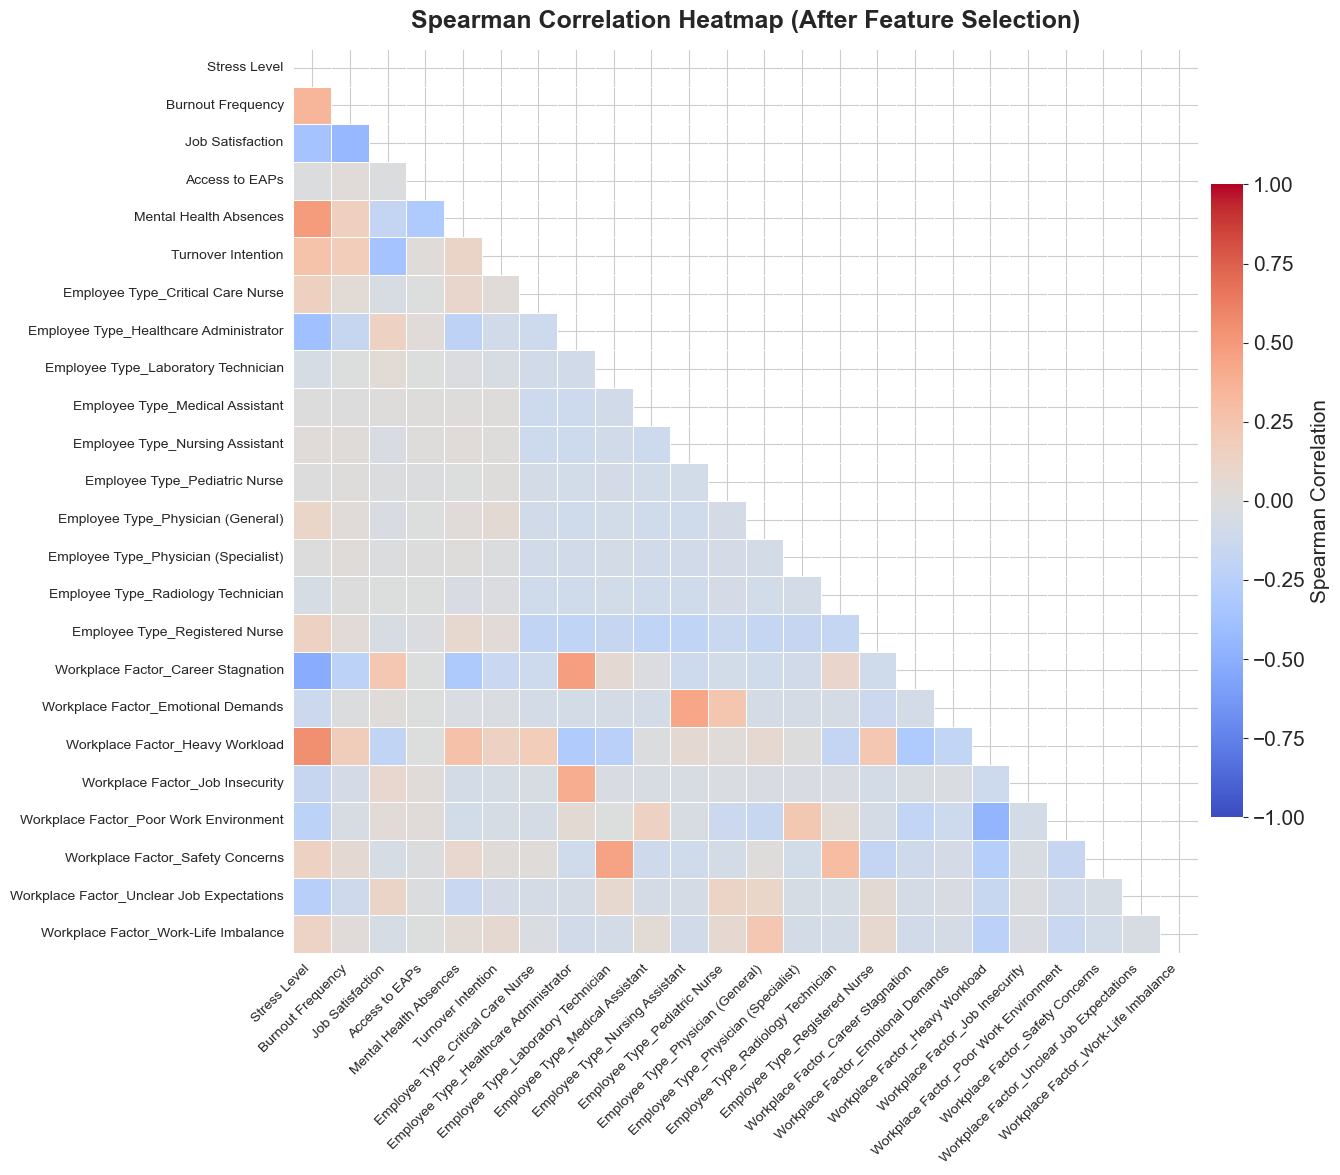

In [180]:
# SPEARMAN CORRELATION HEATMAP – WITH SAVE OPTION
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.rcParams['figure.figsize'] = (16, 12)
plt.rcParams['font.size'] = 15

corr = df.corr(method='spearman', numeric_only=True)

mask = np.triu(np.ones_like(corr, dtype=bool))

output_folder = "correlation_maps"
os.makedirs(output_folder, exist_ok=True)
output_file = os.path.join(output_folder, "spearman_correlation_heatmap_afterselection.png")

plt.figure(figsize=(16, 12))
sns.heatmap(
    corr,
    mask=mask,
    cmap='coolwarm',          
    vmin=-1, vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    annot=False,
    cbar_kws={'shrink': 0.7, 'label': 'Spearman Correlation','pad': 0.01 }
)

plt.title("Spearman Correlation Heatmap (After Feature Selection)", fontsize=18, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()

plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f" Correlation heatmap saved successfully at: {output_file}")

plt.show()

In [182]:
df['Turnover Intention'].value_counts()

Turnover Intention
1    3335
0    1665
Name: count, dtype: int64

##### Dados desbalanceados !!!

# Models

### Splitting & Features Selection

In [184]:
from sklearn.model_selection import train_test_split

# VARIAVEL A MODELAR - TURNOVER INTENTION
X = df.drop(['Turnover Intention'], axis=1)

y = df['Turnover Intention']

#  training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# shapes of the train and test sets
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((4000, 23), (1000, 23), (4000,), (1000,))

In [186]:
X_train.head()

,Stress Level,Burnout Frequency,Job Satisfaction,Access to EAPs,Mental Health Absences,Employee Type_Critical Care Nurse,Employee Type_Healthcare Administrator,Employee Type_Laboratory Technician,Employee Type_Medical Assistant,Employee Type_Nursing Assistant,...,Employee Type_Radiology Technician,Employee Type_Registered Nurse,Workplace Factor_Career Stagnation,Workplace Factor_Emotional Demands,Workplace Factor_Heavy Workload,Workplace Factor_Job Insecurity,Workplace Factor_Poor Work Environment,Workplace Factor_Safety Concerns,Workplace Factor_Unclear Job Expectations,Workplace Factor_Work-Life Imbalance
4227,7,1,3,0,5,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
4676,4,1,3,1,0,0,0,0,0,0,...,0,1,1,0,0,0,0,0,0,0
800,8,2,2,0,12,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
3671,7,2,2,1,6,0,0,0,0,0,...,0,1,0,0,1,0,0,0,0,0
4193,8,1,1,0,9,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0


### DecisionTreeClassifier

In [61]:
# Grid pipeline to choose the best combination os parameters
from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'criterion': ['gini', 'entropy']
}

grid = GridSearchCV(
    estimator=DecisionTreeClassifier(class_weight='balanced', random_state=42),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    verbose=1
)

grid.fit(X_train, y_train)
print(grid.best_params_)

Fitting 3 folds for each of 72 candidates, totalling 216 fits
{'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 2}


In [188]:
from sklearn.tree import DecisionTreeClassifier

model2 = DecisionTreeClassifier(criterion = "entropy", max_depth=  5, min_samples_leaf = 5, min_samples_split = 5, class_weight='balanced',random_state=42)
model2.fit(X_train, y_train)

# Make predictions
y_pred = model2.predict(X_test)


In [190]:
from sklearn.metrics import classification_report

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))



Classification Report:

              precision    recall  f1-score   support

           0       0.67      0.54      0.60       319
           1       0.80      0.88      0.84       681

    accuracy                           0.77      1000
   macro avg       0.74      0.71      0.72      1000
weighted avg       0.76      0.77      0.76      1000



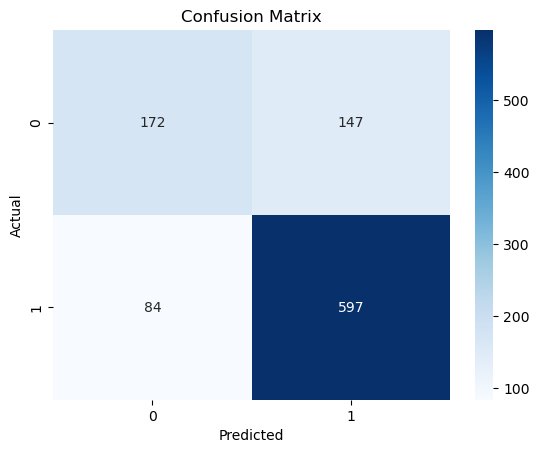

In [67]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

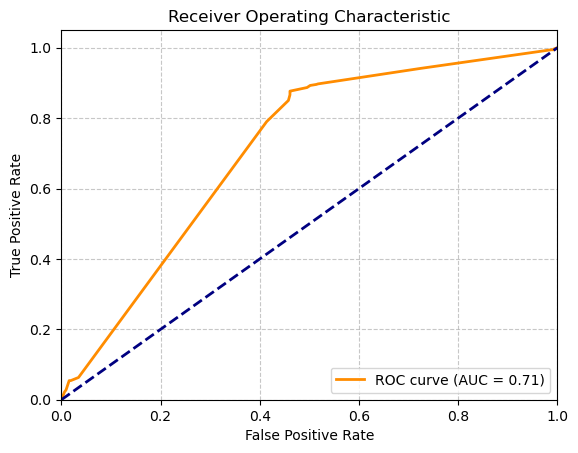

In [69]:
from sklearn.metrics import  roc_curve, auc
fpr, tpr, _ = roc_curve(y_test, model2.predict_proba(X_test)[:, 1])
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### GradientBoostingClassifier

In [96]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'learning_rate': np.linspace(0.01, 0.2, 5),
    'max_depth': [2, 3, 4, 5, 6, 7],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 5, 7],
    'subsample': [0.4, 0.6, 0.8, 1.0]
}

gb = GradientBoostingClassifier(random_state=42)

search = RandomizedSearchCV(
    gb,
    param_distributions=param_dist,
    n_iter=50,             # número de combinações testadas
    scoring='roc_auc',
    cv=10,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

search.fit(X_train, y_train)

print("Melhores parâmetros:", search.best_params_)
print("Melhor AUC (cv):", search.best_score_)


Fitting 10 folds for each of 50 candidates, totalling 500 fits
Melhores parâmetros: {'subsample': 0.8, 'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 2, 'learning_rate': 0.105}
Melhor AUC (cv): 0.7281428752581727


In [302]:

from sklearn.ensemble import GradientBoostingClassifier

model3 = GradientBoostingClassifier(subsample = 0.8, n_estimators = 300, min_samples_split =  10, min_samples_leaf = 1,
                                    max_depth = 2, learning_rate = 0.105, random_state=42)
model3.fit(X_train, y_train)

# Make predictions
y_pred = model3.predict(X_test)

In [304]:
from sklearn.metrics import classification_report

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))



Classification Report:

              precision    recall  f1-score   support

           0       0.68      0.50      0.57       319
           1       0.79      0.89      0.84       681

    accuracy                           0.77      1000
   macro avg       0.74      0.69      0.71      1000
weighted avg       0.76      0.77      0.75      1000



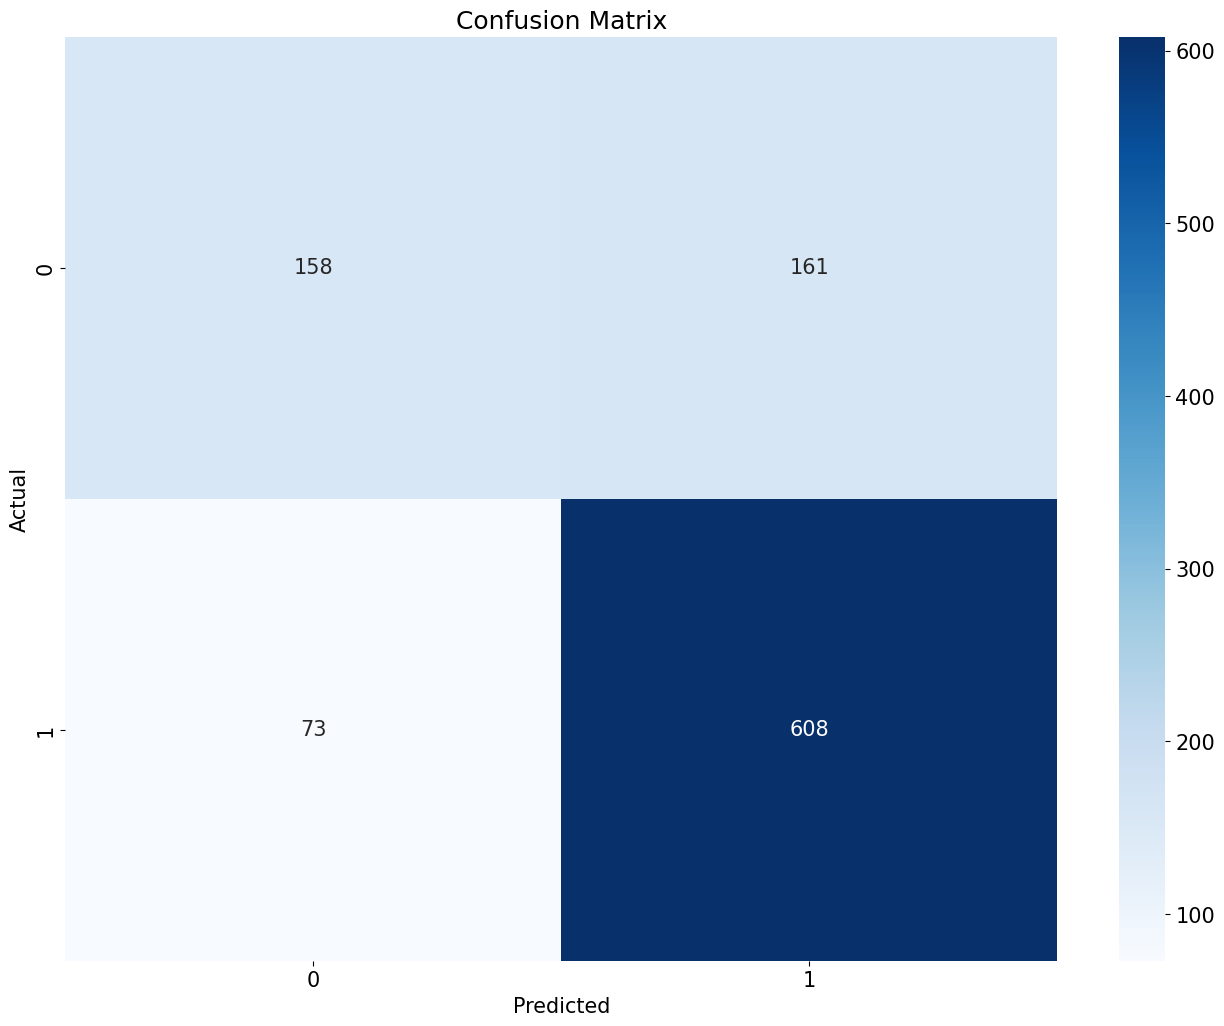

In [306]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

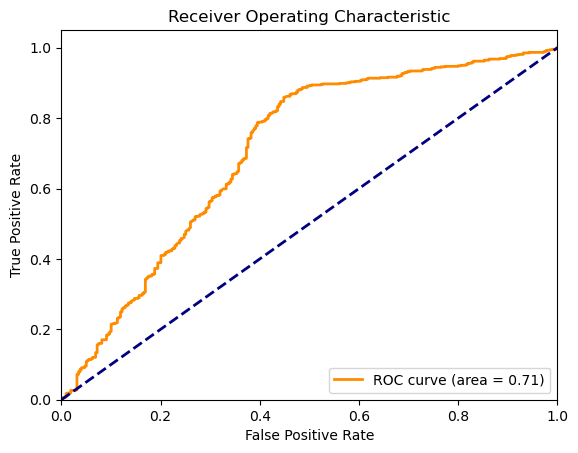

In [116]:
from sklearn.metrics import  roc_curve, auc
fpr, tpr, _ = roc_curve(y_test, model3.predict_proba(X_test)[:, 1])
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

### XGBClassifier

In [118]:
# Grid pipeline >> model tunning
from sklearn.model_selection import GridSearchCV
import xgboost as xgb
from xgboost import XGBClassifier
import numpy as np


param_grid = {
    'max_depth': [2, 3, 4, 5, 6, 7],
    'learning_rate': np.linspace(0.01, 0.2, 5),
    'n_estimators': [100, 200, 300, 400, 500],
    'subsample': [0.4, 0.6, 0.8, 1.0]
}

grid = GridSearchCV(estimator=XGBClassifier(objective='binary:logistic'),
                    param_grid=param_grid,
                    scoring='roc_auc',
                    cv=10,
                    verbose=1)
grid.fit(X_train, y_train)
print(grid.best_params_)


Fitting 10 folds for each of 600 candidates, totalling 6000 fits
{'learning_rate': 0.15250000000000002, 'max_depth': 2, 'n_estimators': 300, 'subsample': 1.0}


In [308]:
from xgboost import XGBClassifier

model4 = XGBClassifier(
    learning_rate=0.15,
    max_depth=2,
    n_estimators=300,
    subsample=1.0,
    objective='binary:logistic',
    eval_metric='auc',
    use_label_encoder=False,
    random_state=42
)


model4.fit(X_train, y_train)

# Make predictions
y_pred = model4.predict(X_test)

In [310]:
from sklearn.metrics import classification_report

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))



Classification Report:

              precision    recall  f1-score   support

           0       0.69      0.50      0.58       319
           1       0.79      0.90      0.84       681

    accuracy                           0.77      1000
   macro avg       0.74      0.70      0.71      1000
weighted avg       0.76      0.77      0.76      1000



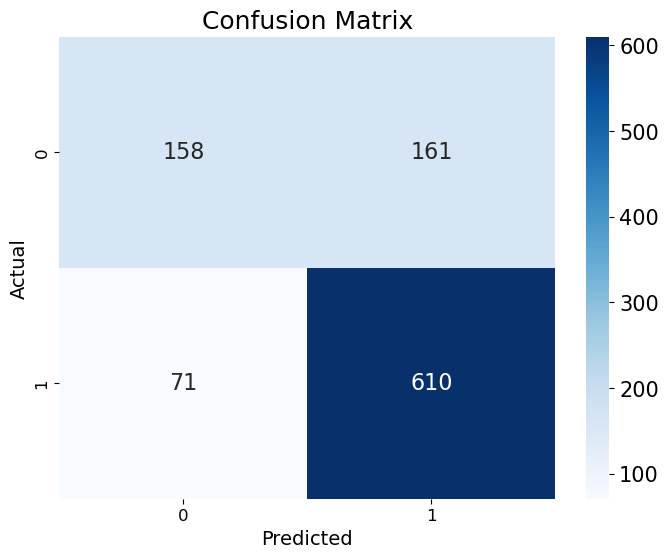

Confusion matrix saved as PNG!


In [324]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

conf_matrix = confusion_matrix(y_test, y_pred)

# Aumentar o tamanho da figura
plt.figure(figsize=(8,6))

# Heatmap com números maiores dentro da matriz
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            annot_kws={"size": 16})  # tamanho dos números

# Títulos e labels maiores
plt.title('Confusion Matrix', fontsize=18)
plt.xlabel('Predicted', fontsize=14)
plt.ylabel('Actual', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Salvar antes de mostrar
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches='tight')

plt.show()
print("Confusion matrix saved as PNG!")


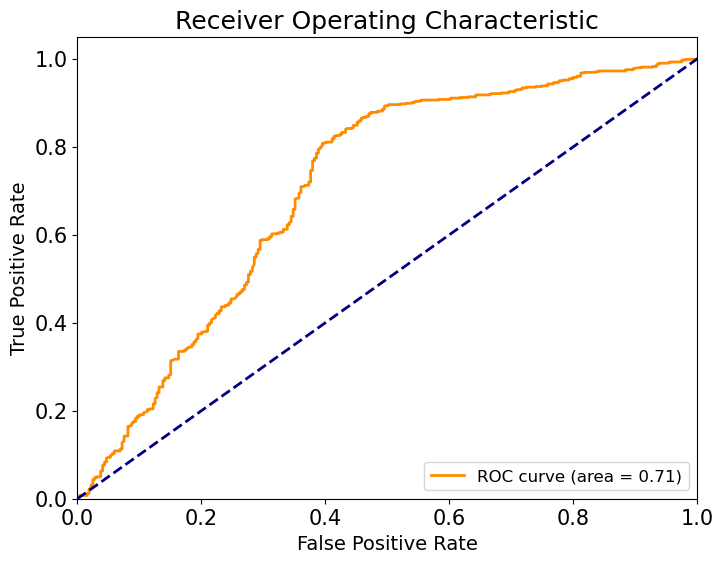

ROC curve saved as PNG!


In [326]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, model4.predict_proba(X_test)[:, 1])
roc_auc = auc(fpr, tpr)

# Aumentar o tamanho da figura
plt.figure(figsize=(8,6))

# Plot ROC
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# Limites dos eixos
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

# Labels e título maiores
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Receiver Operating Characteristic', fontsize=18)

# Legenda com fonte maior
plt.legend(loc='lower right', fontsize=12)

# Salvar em PNG antes de mostrar
plt.savefig("roc_curve.png", dpi=300, bbox_inches='tight')

# Mostrar gráfico
plt.show()
print("ROC curve saved as PNG!")


### SVM

In [130]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler  #Distancias tem de se fazer scaling dos dados

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model5 = SVC(probability=True, class_weight='balanced',random_state=42)
model5.fit(X_train_scaled, y_train)
y_pred = model5.predict(X_test_scaled)

In [132]:
from sklearn.metrics import classification_report

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))



Classification Report:

              precision    recall  f1-score   support

           0       0.56      0.56      0.56       319
           1       0.79      0.79      0.79       681

    accuracy                           0.72      1000
   macro avg       0.68      0.68      0.68      1000
weighted avg       0.72      0.72      0.72      1000



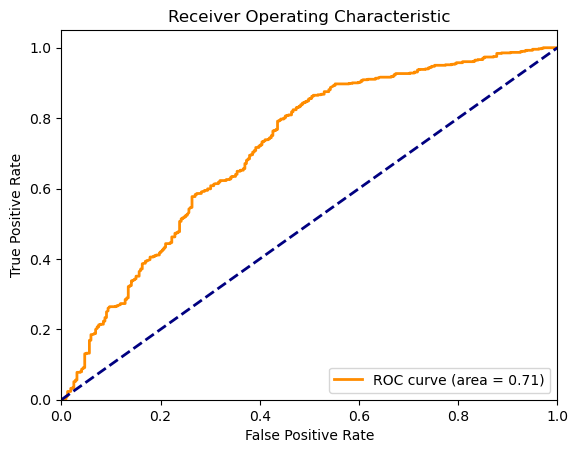

In [134]:
from sklearn.metrics import  roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, model5.predict_proba(X_test_scaled)[:, 1])
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

### K-NN

In [174]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler  
#Distance models
scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


model6 = KNeighborsClassifier(n_neighbors=5, weights='distance')
model6.fit(X_train_scaled, y_train)

y_pred = model6.predict(X_test_scaled)

In [176]:
from sklearn.metrics import classification_report

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))



Classification Report:

              precision    recall  f1-score   support

           0       0.46      0.45      0.46       319
           1       0.75      0.75      0.75       681

    accuracy                           0.66      1000
   macro avg       0.60      0.60      0.60      1000
weighted avg       0.65      0.66      0.66      1000



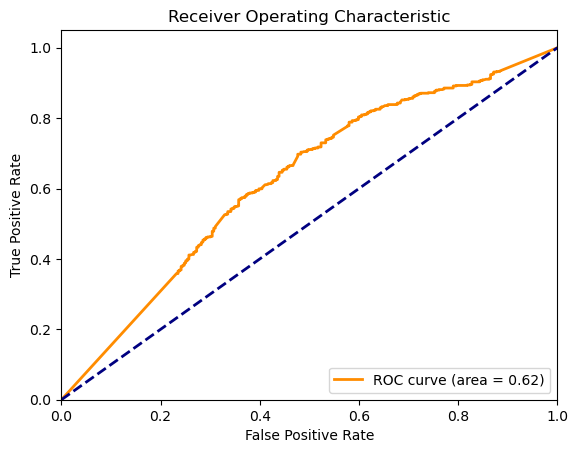

In [482]:
from sklearn.metrics import  roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, model6.predict_proba(X_test_scaled)[:, 1])
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

### Naive Bayes 

In [184]:

from sklearn.naive_bayes import GaussianNB

model7 = GaussianNB()
model7.fit(X_train, y_train)

# Make predictions
y_pred = model7.predict(X_test)

In [186]:
#PERFOMANCE EVALUATION

from sklearn.metrics import classification_report

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))




Classification Report:

              precision    recall  f1-score   support

           0       0.54      0.43      0.48       319
           1       0.76      0.83      0.79       681

    accuracy                           0.70      1000
   macro avg       0.65      0.63      0.63      1000
weighted avg       0.69      0.70      0.69      1000



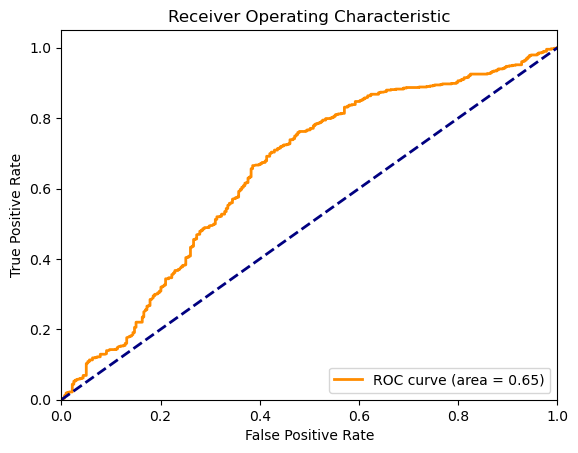

In [188]:

from sklearn.metrics import  roc_curve, auc
fpr, tpr, _ = roc_curve(y_test, model7.predict_proba(X_test)[:, 1])
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

### Radom Forest

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Melhores parâmetros: {'class_weight': 'balanced', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 100}
Melhor AUC (CV): 0.7229179322314815

Classification Report:

              precision    recall  f1-score   support

           0       0.61      0.58      0.60       319
           1       0.81      0.83      0.82       681

    accuracy                           0.75      1000
   macro avg       0.71      0.70      0.71      1000
weighted avg       0.75      0.75      0.75      1000



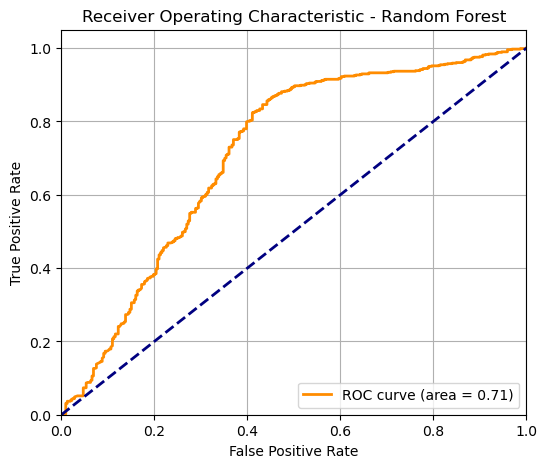

In [191]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, roc_curve, auc
import matplotlib.pyplot as plt


param_grid = {
    'n_estimators': [100, 200, 300],           # número de árvores
    'max_depth': [None, 5, 10, 15],           # profundidade máxima
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2', None],   # features usadas em cada split
    'class_weight': ['balanced']              # importante se classes desbalanceadas
}

# ------------------------------
# GridSearchCV
# ------------------------------
grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    scoring='roc_auc',   # podemos usar 'accuracy', 'f1', etc.
    cv=5,
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Melhores parâmetros:", grid.best_params_)
print("Melhor AUC (CV):", grid.best_score_)


best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]


print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Random Forest')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


### Binary Logistic Regression

In [192]:
import statsmodels.api as sm
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# intercept
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

logit_model = sm.Logit(y_train, X_train_const)
result = logit_model.fit()

y_pred = result.predict(X_test_const)
y_pred_classic = (y_pred > 0.5).astype(int)


Optimization terminated successfully.
         Current function value: 0.557146
         Iterations 6


In [194]:
from sklearn.metrics import classification_report

print("\nClassification Report - Linear (Classical):\n")
print(classification_report(y_test, y_pred_classic))


Classification Report - Linear (Classical):

              precision    recall  f1-score   support

           0       0.68      0.42      0.52       319
           1       0.77      0.91      0.83       681

    accuracy                           0.75      1000
   macro avg       0.72      0.66      0.67      1000
weighted avg       0.74      0.75      0.73      1000



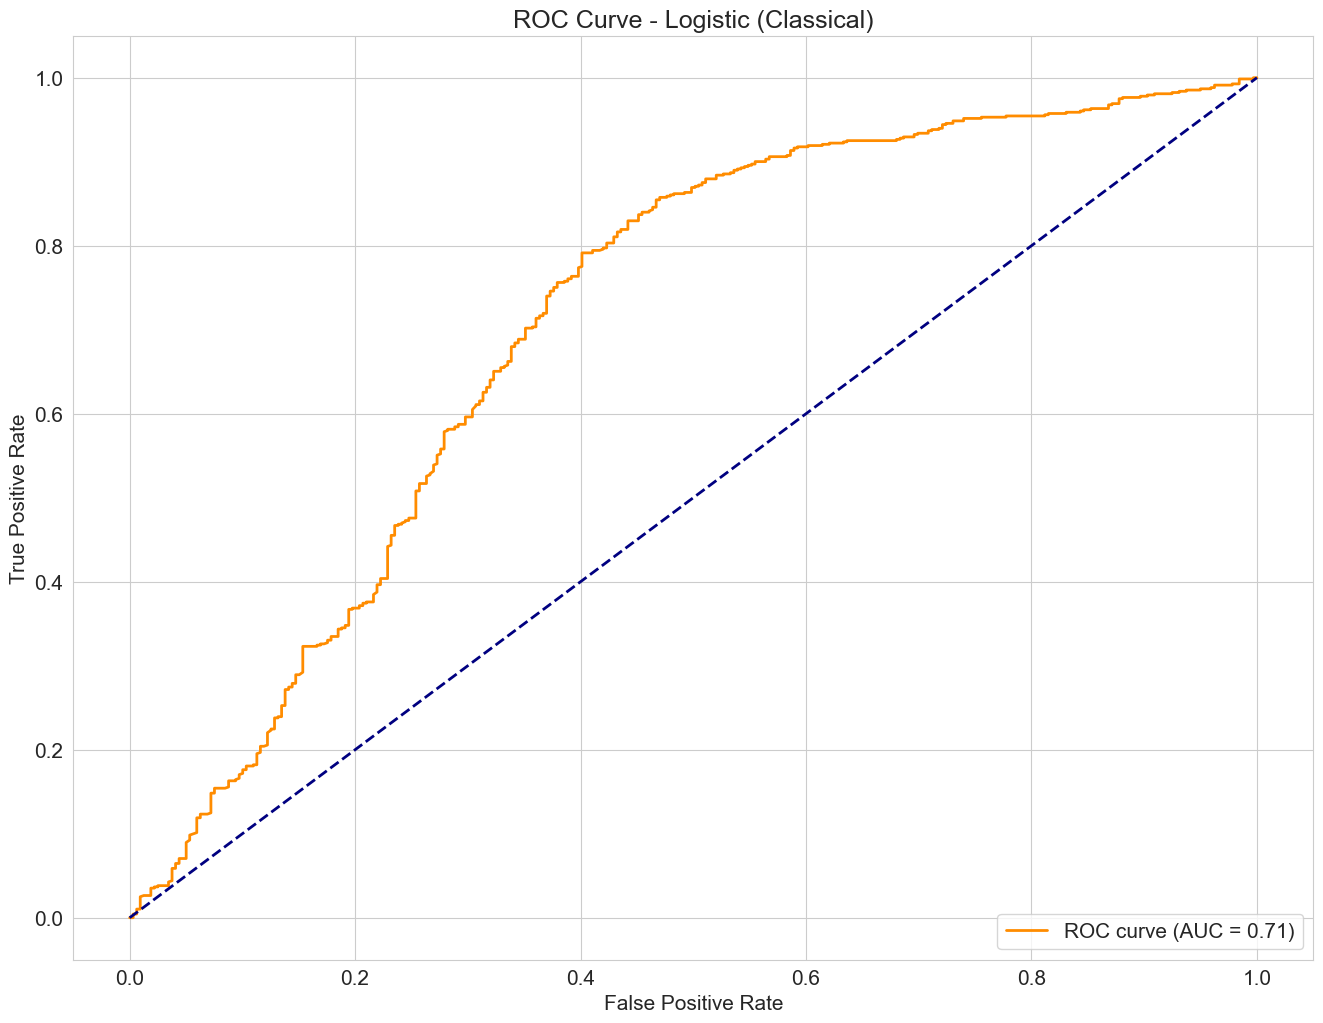

In [196]:

fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic (Classical)')
plt.legend(loc='lower right')
plt.show()

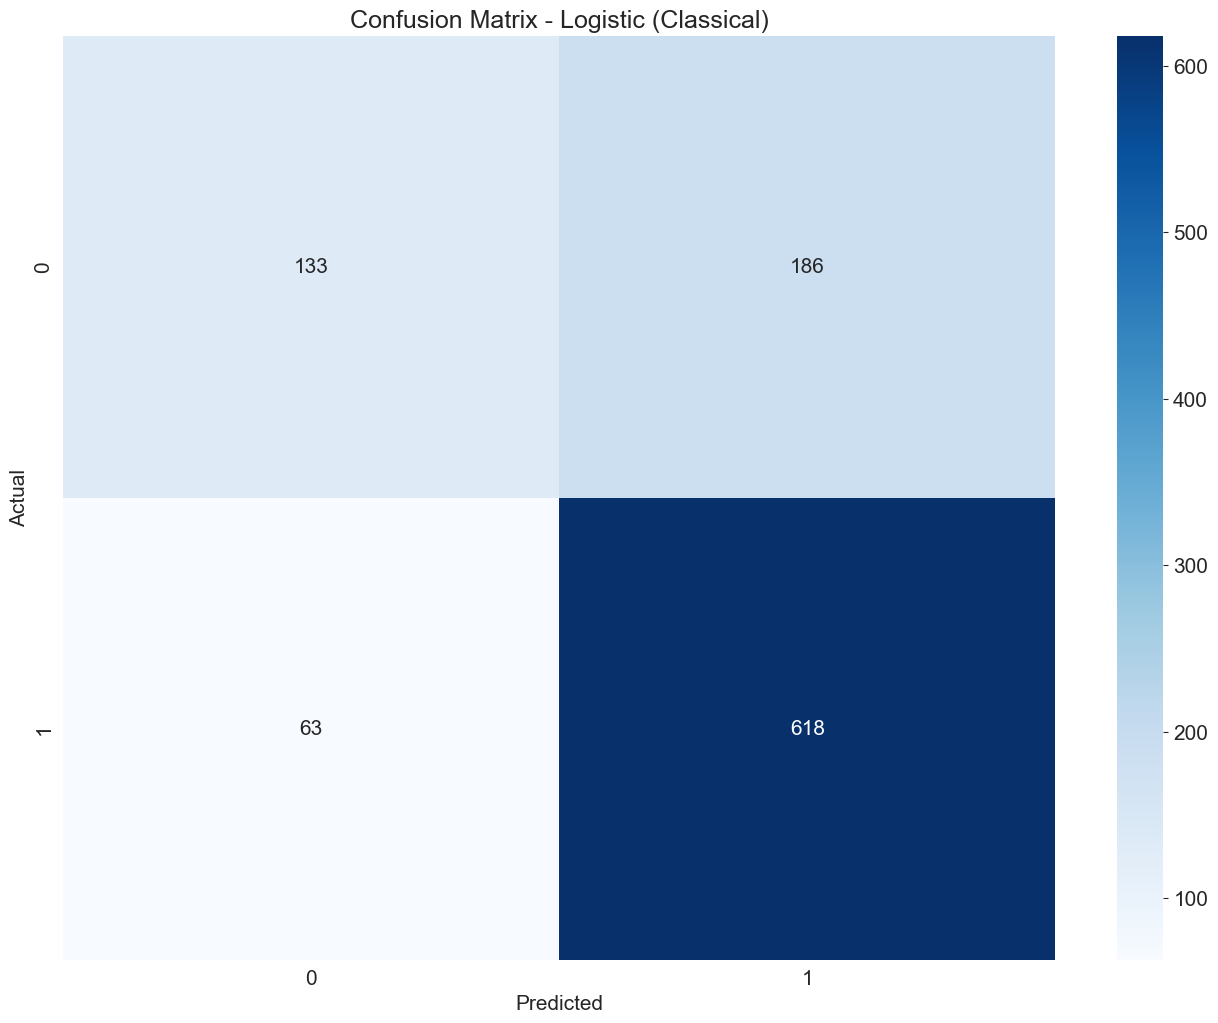

In [198]:
# --- Avaliação: Confusion Matrix ---
conf_matrix_classic = confusion_matrix(y_test, y_pred_classic)
sns.heatmap(conf_matrix_classic, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic (Classical)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [200]:
print(result.summary())

                           Logit Regression Results                           
Dep. Variable:     Turnover Intention   No. Observations:                 4000
Model:                          Logit   Df Residuals:                     3978
Method:                           MLE   Df Model:                           21
Date:                Sun, 16 Nov 2025   Pseudo R-squ.:                  0.1277
Time:                        15:22:32   Log-Likelihood:                -2228.6
converged:                       True   LL-Null:                       -2554.7
Covariance Type:            nonrobust   LLR p-value:                1.533e-124
                                                coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
const                                        -0.0252        nan        nan        nan         nan         nan
Stress Level                          

EXTREMELY MULTICOLINEARITY... or VARIABLES WITH VERY UNEVEN DISTRIBUTION

In [202]:
# UNEVEN DISTRIBUTION
for col in df.columns:
    if df[col].nunique() == 2: 
        print(col, df[col].value_counts())


Access to EAPs Access to EAPs
1    3594
0    1406
Name: count, dtype: int64
Turnover Intention Turnover Intention
1    3335
0    1665
Name: count, dtype: int64
Employee Type_Critical Care Nurse Employee Type_Critical Care Nurse
0    4512
1     488
Name: count, dtype: int64
Employee Type_Healthcare Administrator Employee Type_Healthcare Administrator
0    4493
1     507
Name: count, dtype: int64
Employee Type_Laboratory Technician Employee Type_Laboratory Technician
0    4646
1     354
Name: count, dtype: int64
Employee Type_Medical Assistant Employee Type_Medical Assistant
0    4487
1     513
Name: count, dtype: int64
Employee Type_Nursing Assistant Employee Type_Nursing Assistant
0    4498
1     502
Name: count, dtype: int64
Employee Type_Pediatric Nurse Employee Type_Pediatric Nurse
0    4738
1     262
Name: count, dtype: int64
Employee Type_Physician (General) Employee Type_Physician (General)
0    4628
1     372
Name: count, dtype: int64
Employee Type_Physician (Specialist) Employe

In [204]:
# --- Odds Ratios ---
odds_ratios = np.exp(result.params)
print("\nOdds Ratios:\n", odds_ratios)


Odds Ratios:
 const                                        0.975158
Stress Level                                 1.433201
Burnout Frequency                            0.898616
Job Satisfaction                             0.498009
Access to EAPs                               1.060842
Mental Health Absences                       0.987559
Employee Type_Critical Care Nurse            1.075061
Employee Type_Healthcare Administrator       1.098464
Employee Type_Laboratory Technician          0.899674
Employee Type_Medical Assistant              0.978965
Employee Type_Nursing Assistant              0.951861
Employee Type_Pediatric Nurse                0.910160
Employee Type_Physician (General)            1.320721
Employee Type_Physician (Specialist)         0.832939
Employee Type_Radiology Technician           1.019096
Employee Type_Registered Nurse               0.965323
Workplace Factor_Career Stagnation           1.385936
Workplace Factor_Emotional Demands           0.967331
Workplace Fac

Odds ratio: indica quanto os odds mudam com variação unitária de uma variável.

OR > 1 → aumento do risco do evento

OR < 1 → redução do risco

#### MODEL IMPROVEMENT With Less Variables

In [207]:
import statsmodels.api as sm

vars_sig = ["Stress Level", "Job Satisfaction"]

X_train_sig = X_train[vars_sig]
X_test_sig = X_test[vars_sig]

# Adicionar intercepto
X_train_sig_const = sm.add_constant(X_train_sig)
X_test_sig_const = sm.add_constant(X_test_sig)


logit_model = sm.Logit(y_train,  X_train_sig_const)
result = logit_model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.561243
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:     Turnover Intention   No. Observations:                 4000
Model:                          Logit   Df Residuals:                     3997
Method:                           MLE   Df Model:                            2
Date:                Sun, 16 Nov 2025   Pseudo R-squ.:                  0.1213
Time:                        15:24:18   Log-Likelihood:                -2245.0
converged:                       True   LL-Null:                       -2554.7
Covariance Type:            nonrobust   LLR p-value:                2.929e-135
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.5276      0.239      2.210      0.027       0.060       0.996
Stress Leve

In [209]:
y_pred = result.predict(X_test_sig_const)
y_pred_classic = (y_pred > 0.5).astype(int)

In [211]:
from sklearn.metrics import classification_report

print("\nClassification Report - Logistic (Classical):\n")
print(classification_report(y_test, y_pred_classic))


Classification Report - Logistic (Classical):

              precision    recall  f1-score   support

           0       0.68      0.43      0.52       319
           1       0.77      0.90      0.83       681

    accuracy                           0.75      1000
   macro avg       0.72      0.67      0.68      1000
weighted avg       0.74      0.75      0.73      1000



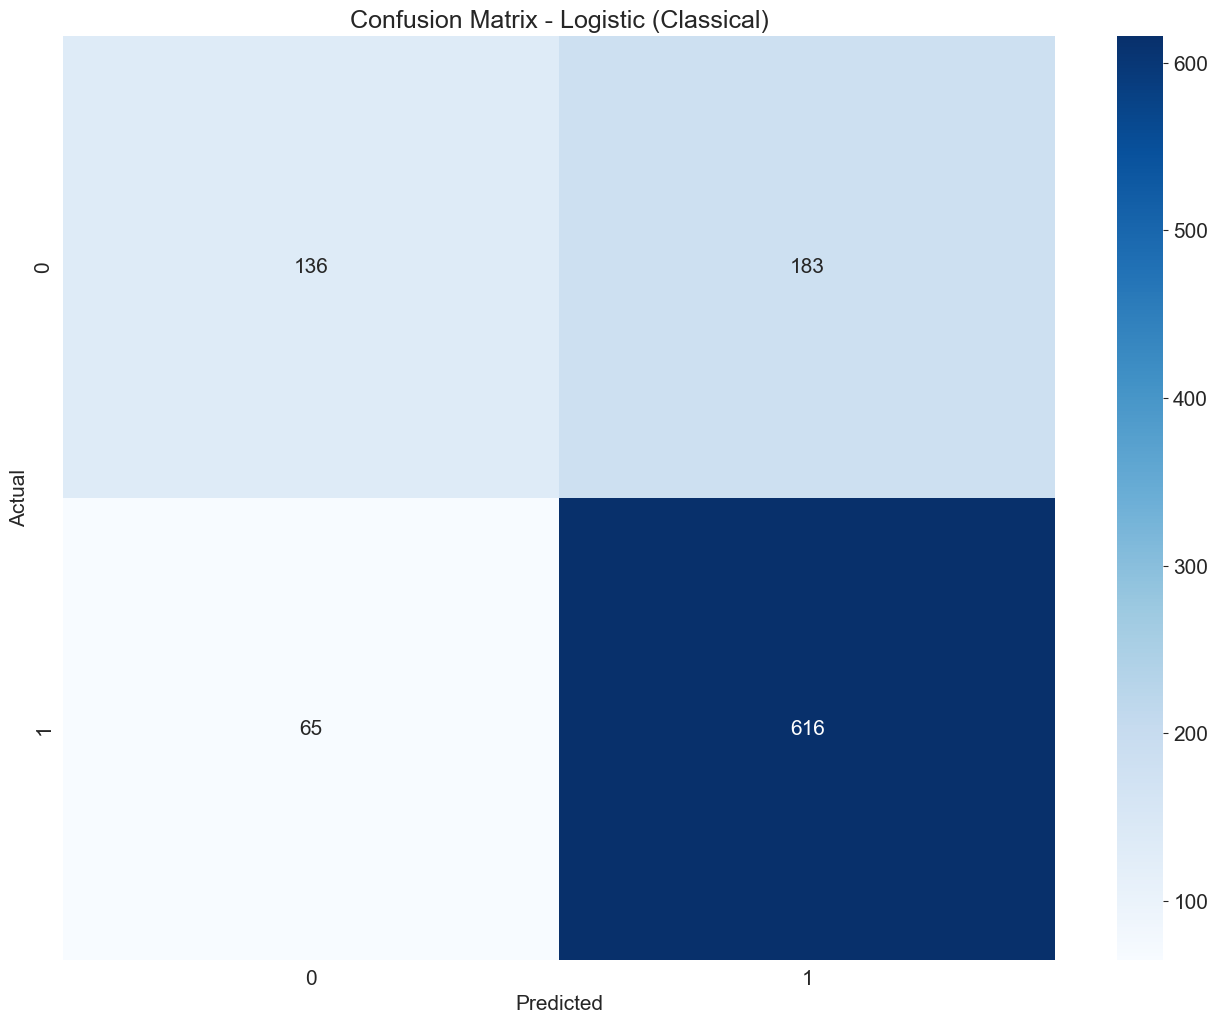

In [213]:
conf_matrix_classic = confusion_matrix(y_test, y_pred_classic)
sns.heatmap(conf_matrix_classic, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic (Classical)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

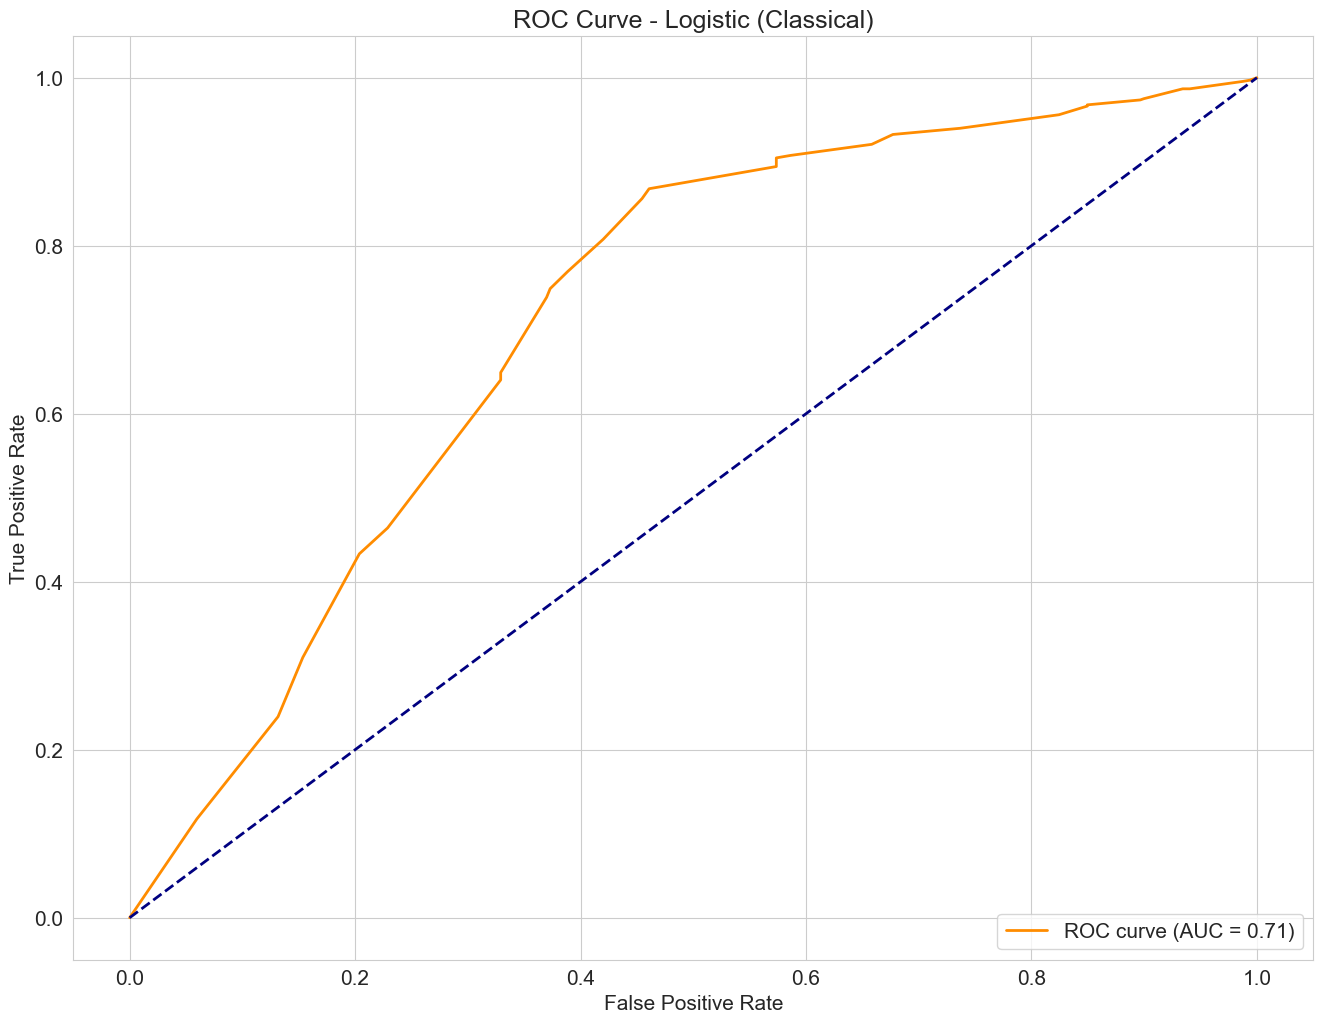

In [215]:
fpr, tpr, _ = roc_curve(y_test, y_pred)

roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic (Classical)')
plt.legend(loc='lower right')
plt.show()

# Simulations using XGBOOST

#### % of Turnover Intention in original TestSet 

In [217]:
import numpy as np
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
import os
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

model4 = XGBClassifier(
    learning_rate=0.15,
    max_depth=2,
    n_estimators=300,
    subsample=1.0,
    objective='binary:logistic',
    eval_metric='auc',
    use_label_encoder=False,
    random_state=42
)


model4.fit(X_train, y_train)

y_pred_base = model4.predict(X_test)
turnover_base = np.mean(y_pred_base)
print(f"Turnover base: {turnover_base:.3f}")



Turnover base: 0.771


#### One Feature Simulations

##### Burnout Frequency Simulation

In [329]:
# BURNOUT FREQUENCY
X_sim_burnout = X_test.copy()
##########################################################################################
###########################################################################################

# burnout: se for 2→1, se for 1→0, se for 0 fica 0; ou  aumentar 0→1, 1→2, 2 fica 2
#X_sim_burnout['Burnout Frequency'] = X_sim_burnout['Burnout Frequency'].map(lambda x: max(x-1, 0))
X_sim_burnout['Burnout Frequency'] = X_sim_burnout['Burnout Frequency'].map(lambda x: min(x + 1, 2))

y_pred_sim = model4.predict(X_sim_burnout)
turnover_sim_burnout = np.mean(y_pred_sim)
print(f"Turnover burnout simulado: {turnover_sim_burnout:.3f}")

print(f"Δ = {turnover_sim_burnout - turnover_base:.3f}")



Turnover burnout simulado: 0.769
Δ = -0.002


In [331]:
def plot_burnout_bars(df_before, df_after, folder='burnout_graphs', palette='Set2', save=True):
    """
    Generates two separate bar charts showing the distribution of Burnout Frequency
    before and after the transformation.
    """

    if save:
        os.makedirs(folder, exist_ok=True)

    sns.set_style("whitegrid")
    plt.rcParams['figure.figsize'] = (10, 6)
    plt.rcParams['font.size'] = 15

    # ==============================
    # 1. Bar chart – Before transformation
    # ==============================
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.countplot(
        data=df_before,
        x='Burnout Frequency',
        palette=palette,
        ax=ax,
        edgecolor='black'
    )

    ax.set_title('Burnout Frequency Distribution – Before Transformation', fontsize=22, fontweight='bold', pad=15)
    ax.set_xlabel('Burnout Frequency', fontsize=16, fontweight='bold')
    ax.set_ylabel('Count', fontsize=16, fontweight='bold')
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()

    if save:
        file_name_before = os.path.join(folder, 'Bar_Burnout_Frequency_Before.png')
        plt.savefig(file_name_before, dpi=300, bbox_inches='tight')
        print(f" Plot saved to: {file_name_before}")

    plt.show()

    # ==============================
    # 2. Bar chart – After transformation
    # ==============================
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.countplot(
        data=df_after,
        x='Burnout Frequency',
        palette=palette,
        ax=ax,
        edgecolor='black'
    )

    ax.set_title('Burnout Frequency Distribution – After Transformation', fontsize=22, fontweight='bold', pad=15)
    ax.set_xlabel('Burnout Frequency', fontsize=16, fontweight='bold')
    ax.set_ylabel('Count', fontsize=16, fontweight='bold')
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()

    if save:
        file_name_after = os.path.join(folder, 'Bar_Burnout_Frequency_After.png')
        plt.savefig(file_name_after, dpi=300, bbox_inches='tight')
        print(f" Plot saved to: {file_name_after}")

    plt.show()


C:\Users\35192\AppData\Local\Temp\ipykernel_13872\2111744956.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


 Plot saved to: burnout_graphs\Bar_Burnout_Frequency_Before.png


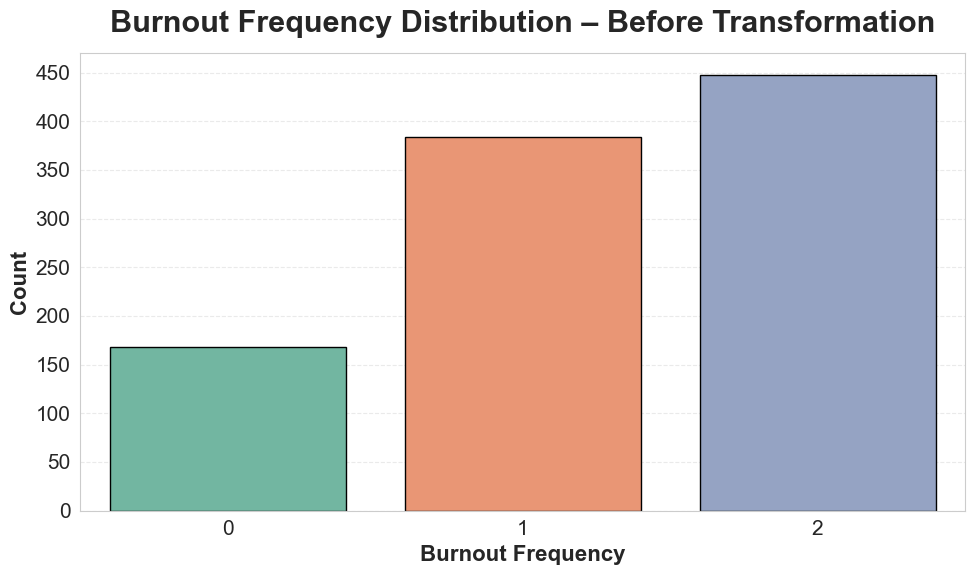

C:\Users\35192\AppData\Local\Temp\ipykernel_13872\2111744956.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


 Plot saved to: burnout_graphs\Bar_Burnout_Frequency_After.png


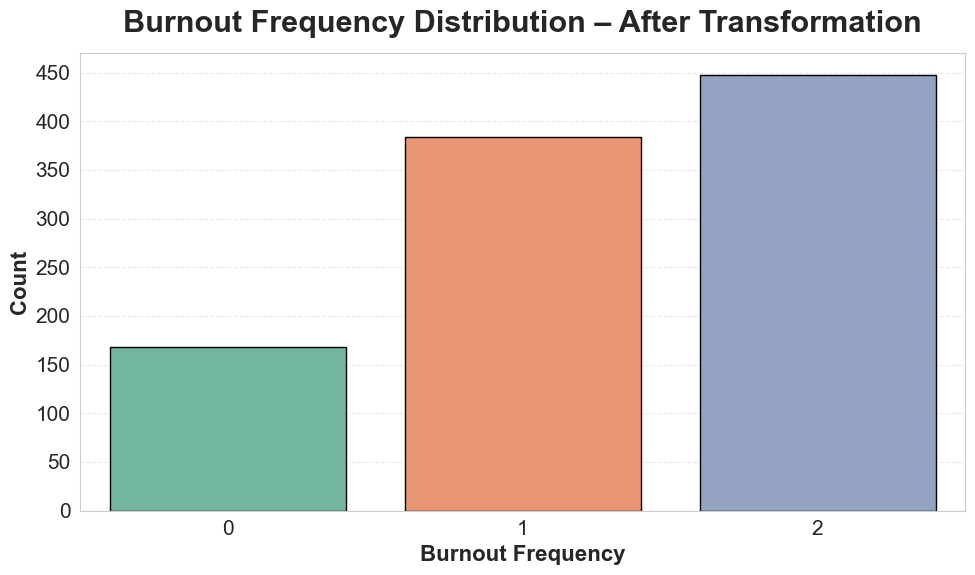

In [333]:
plot_burnout_bars(X_test, X_sim)

##### Job Satisfaction Simulation

In [367]:
#JOB SATISFACTION
X_sim_job = X_test.copy()

# aumentar satisfação: +1, mas nunca mais que 5
#X_sim['Job Satisfaction']  = (X_sim['Job Satisfaction'] - 1).clip(lower=1)  # Este aqui está bem
X_sim_job['Job Satisfaction']  = (X_sim_job['Job Satisfaction'] + 1).clip(upper=5)  # Este aqui está bem

y_pred_sim = model4.predict(X_sim_job)
turnover_sim_job = np.mean(y_pred_sim)
print(f"Turnover burnout simulado: {turnover_sim:.3f}")

print(f"Δ = {turnover_sim_job - turnover_base:.3f}")

Turnover burnout simulado: 0.637
Δ = -0.134


In [337]:
def plot_job_satisfaction_boxplot(df_before, df_after, folder='job_satisfaction_graphs', palette='coolwarm', save=True):
    """
    Generates a boxplot showing the distribution of Job Satisfaction before and after transformation.
    """

    if save:
        os.makedirs(folder, exist_ok=True)

    # Combine data for plotting
    df_plot = pd.DataFrame({
        'Job Satisfaction': pd.concat([df_before['Job Satisfaction'], df_after['Job Satisfaction']]),
        'State': ['Before'] * len(df_before) + ['After'] * len(df_after)
    })

    sns.set_style("whitegrid")
    plt.rcParams['figure.figsize'] = (10, 6)
    plt.rcParams['font.size'] = 15

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.boxplot(
        data=df_plot,
        x='State',
        y='Job Satisfaction',
        palette=palette,
        width=0.6,
        linewidth=1.2,
        ax=ax
    )

    ax.set_title('Job Satisfaction Distribution', fontsize=22, fontweight='bold', pad=15)
    ax.set_xlabel('', fontsize=16, fontweight='bold')
    ax.set_ylabel('Job Satisfaction', fontsize=16, fontweight='bold')
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()

    if save:
        file_name = os.path.join(folder, 'Boxplot_Job_Satisfaction_Before_After.png')
        plt.savefig(file_name, dpi=300, bbox_inches='tight')
        print(f"Plot saved to: {file_name}")

    plt.show()

C:\Users\35192\AppData\Local\Temp\ipykernel_13872\3721576374.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Plot saved to: job_satisfaction_graphs\Boxplot_Job_Satisfaction_Before_After.png


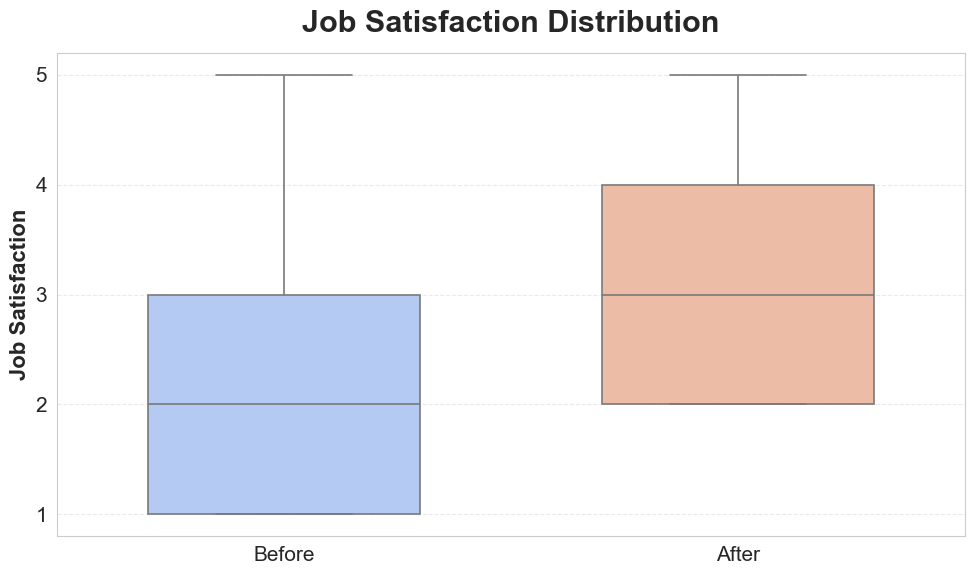

In [339]:
plot_job_satisfaction_boxplot(X_test, X_sim)

##### Access to EAPS Simulation

In [341]:
#ACCESS TO EAPS
X_sim_eap = X_test.copy()

#Reduzir Access to EAPs

mask_1 = X_sim_eap['Access to EAPs'] == 1

# escolhe 70 % dessas linhas ao acaso

idx_to_flip = X_sim_eap[mask_1].sample(frac=0.70, random_state=42).index

# muda essas para 0
X_sim_eap.loc[idx_to_flip, 'Access to EAPs'] = 0

y_pred_sim = model4.predict(X_sim_eap)
turnover_sim_eap = np.mean(y_pred_sim)
print(f"Turnover EAP Access simulado: {turnover_sim_eap:.3f}")

print(f"Δ = {turnover_sim_eap - turnover_base:.3f}")


Turnover EAP Access simulado: 0.770
Δ = -0.001


In [343]:
def plot_access_to_eaps_bar(df_before, df_after, folder='access_to_eaps_graphs', palette='pastel', save=True):
    """
    Generates two bar charts showing the distribution of Access to EAPs (Employee Assistance Programs)
    before and after the transformation.
    """

    if save:
        os.makedirs(folder, exist_ok=True)

    sns.set_style("whitegrid")
    plt.rcParams['figure.figsize'] = (8, 6)
    plt.rcParams['font.size'] = 15

    # ======================================
    # 1. Bar Chart – Before Transformation
    # ======================================
    fig, ax = plt.subplots(figsize=(8, 6))
    access_counts_before = df_before['Access to EAPs'].value_counts().sort_index()

    sns.barplot(
        x=access_counts_before.index,
        y=access_counts_before.values,
        palette=palette,
        ax=ax
    )

    ax.set_title('Access to EAPs – Before Transformation', fontsize=20, fontweight='bold', pad=15)
    ax.set_xlabel('Access to EAPs ("No" = 0, "Yes" = 1)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Number of Employees', fontsize=14, fontweight='bold')
    ax.bar_label(ax.containers[0], fontsize=12)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()

    if save:
        file_before = os.path.join(folder, 'Bar_Access_to_EAPs_Before.png')
        plt.savefig(file_before, dpi=300, bbox_inches='tight')
        print(f" Plot saved to: {file_before}")

    plt.show()

    # ======================================
    # 2. Bar Chart – After Transformation
    # ======================================
    fig, ax = plt.subplots(figsize=(8, 6))
    access_counts_after = df_after['Access to EAPs'].value_counts().sort_index()

    sns.barplot(
        x=access_counts_after.index,
        y=access_counts_after.values,
        palette=palette,
        ax=ax
    )

    ax.set_title('Access to EAPs – After Transformation', fontsize=20, fontweight='bold', pad=15)
    ax.set_xlabel('Access to EAPs ("No" = 0, "Yes" = 1)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Number of Employees', fontsize=14, fontweight='bold')
    ax.bar_label(ax.containers[0], fontsize=12)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()

    if save:
        file_after = os.path.join(folder, 'Bar_Access_to_EAPs_After.png')
        plt.savefig(file_after, dpi=300, bbox_inches='tight')
        print(f" Plot saved to: {file_after}")

    plt.show()


C:\Users\35192\AppData\Local\Temp\ipykernel_13872\77281801.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


 Plot saved to: access_to_eaps_graphs\Bar_Access_to_EAPs_Before.png


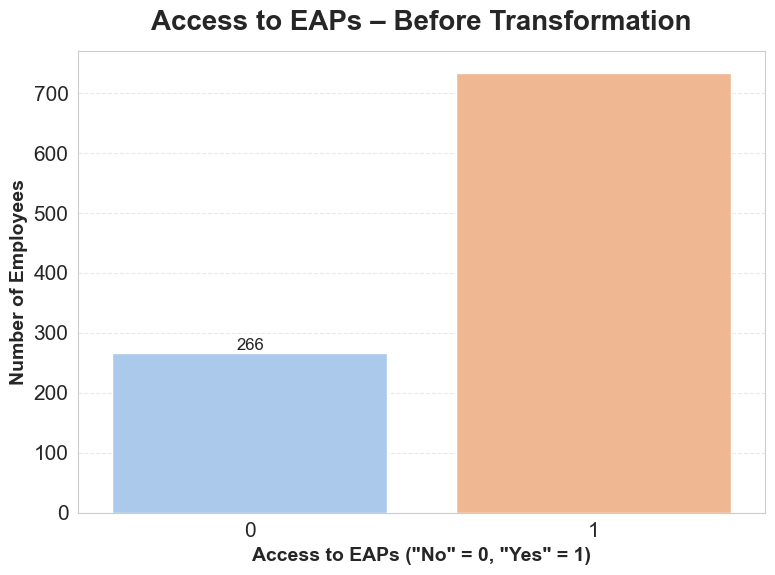

C:\Users\35192\AppData\Local\Temp\ipykernel_13872\77281801.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


 Plot saved to: access_to_eaps_graphs\Bar_Access_to_EAPs_After.png


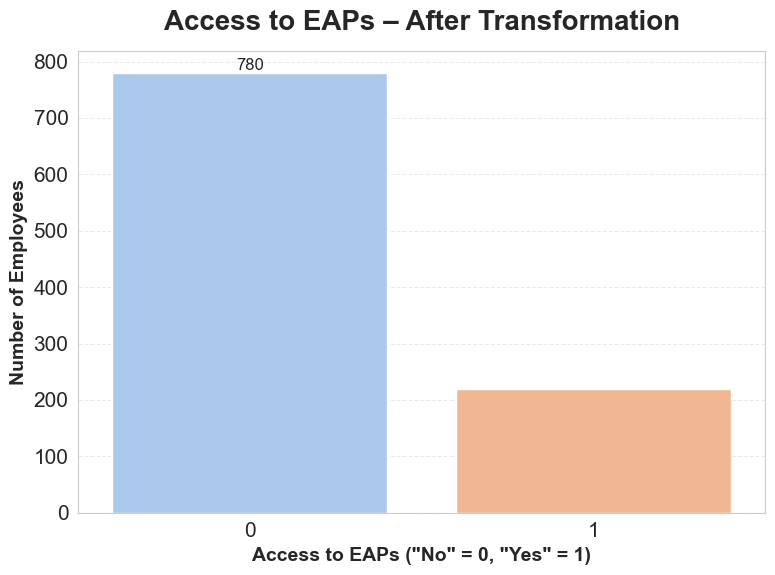

In [345]:
plot_access_to_eaps_bar(X_test, X_sim_eap)

##### Mental Health Absences Simulation

In [347]:
#MENTAL HEALTH ABSENCES
X_sim_mental = X_test.copy()
##########################################################################################
###########################################################################################

#X_sim_mental['Mental Health Absences']  = (X_sim_mental['Mental Health Absences'] - 2).clip(lower=0)  
X_sim_mental['Mental Health Absences']  = (X_sim_mental['Mental Health Absences'] + 5).clip(upper=19)  

##########################################################################################
#########################################################################################
y_pred_sim = model4.predict(X_sim_mental)
turnover_sim_mental = np.mean(y_pred_sim)
print(f"Turnover burnout simulado: {turnover_sim_mental:.3f}")

print(f"Δ = {turnover_sim_mental - turnover_base:.3f}")


Turnover burnout simulado: 0.763
Δ = -0.008


In [349]:
def plot_mental_health_absences_hist(df_before, df_after, folder='mental_health_graphs', palette='viridis', save=True):
    """
    Generates two separate histograms showing the distribution of Mental Health Absences
    before and after the transformation.
    """

    if save:
        os.makedirs(folder, exist_ok=True)

    sns.set_style("whitegrid")
    plt.rcParams['figure.figsize'] = (10, 6)
    plt.rcParams['font.size'] = 15

    # ==============================
    # 1. Histogram – Before transformation
    # ==============================
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.histplot(
        data=df_before,
        x='Mental Health Absences',
        bins=20,
        kde=True,
        color=sns.color_palette(palette)[2],
        edgecolor='black',
        ax=ax
    )

    ax.set_title('Mental Health Absences – Before Transformation', fontsize=22, fontweight='bold', pad=15)
    ax.set_xlabel('Number of Mental Health Absences', fontsize=16, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=16, fontweight='bold')
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()

    if save:
        file_before = os.path.join(folder, 'Histogram_Mental_Health_Absences_Before.png')
        plt.savefig(file_before, dpi=300, bbox_inches='tight')
        print(f" Plot saved to: {file_before}")

    plt.show()

    # ==============================
    # 2. Histogram – After transformation
    # ==============================
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.histplot(
        data=df_after,
        x='Mental Health Absences',
        bins=20,
        kde=True,
        color=sns.color_palette(palette)[4],
        edgecolor='black',
        ax=ax
    )

    ax.set_title('Mental Health Absences – After Transformation', fontsize=22, fontweight='bold', pad=15)
    ax.set_xlabel('Number of Mental Health Absences', fontsize=16, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=16, fontweight='bold')
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()

    if save:
        file_after = os.path.join(folder, 'Histogram_Mental_Health_Absences_After.png')
        plt.savefig(file_after, dpi=300, bbox_inches='tight')
        print(f" Plot saved to: {file_after}")

    plt.show()

 Plot saved to: mental_health_graphs\Histogram_Mental_Health_Absences_Before.png


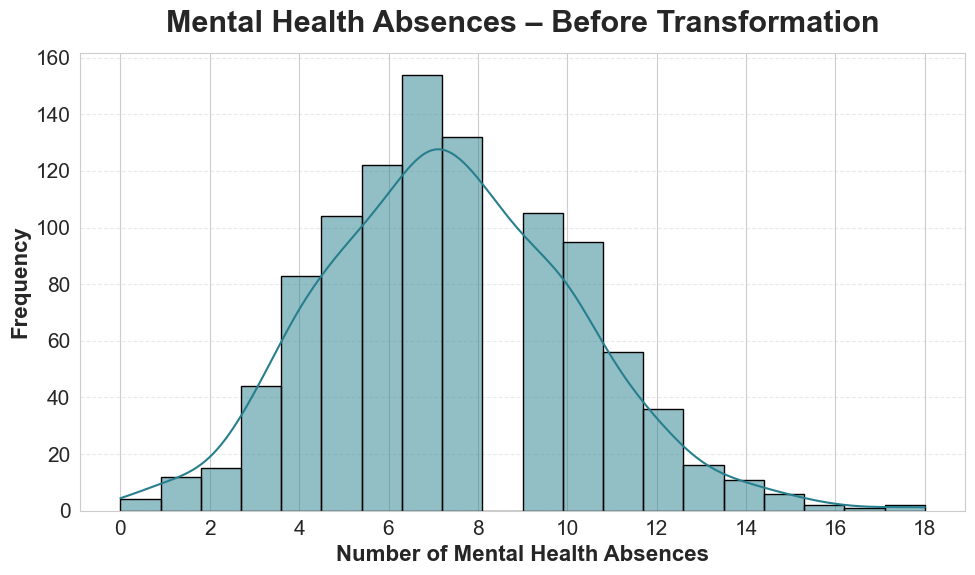

 Plot saved to: mental_health_graphs\Histogram_Mental_Health_Absences_After.png


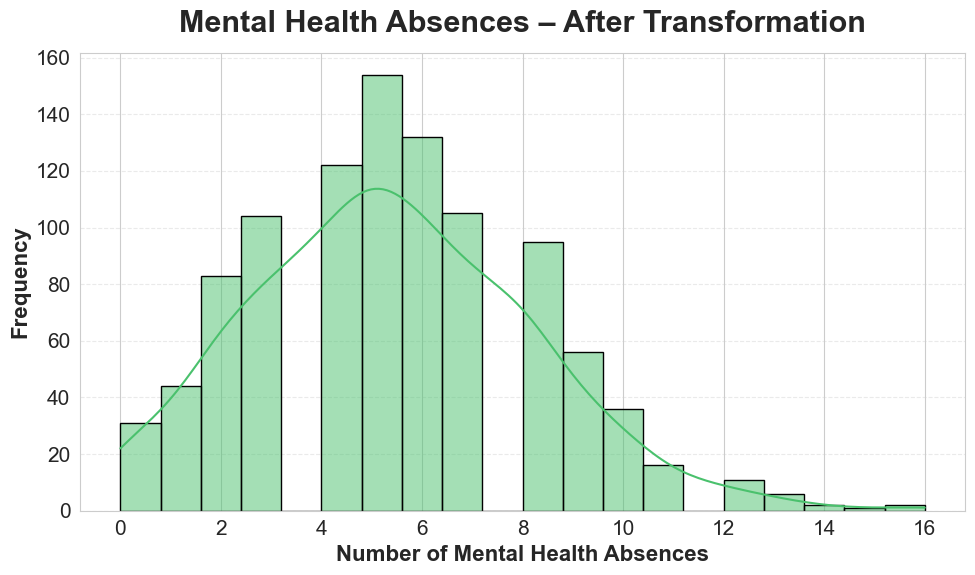

In [293]:
plot_mental_health_absences_hist(X_test, X_sim)

##### Stress Level Simulation

In [351]:
#Stress level
X_sim_stress = X_test.copy()

#Inverter a distibuição dos níveis de stress
max_val, min_val = max(X_sim_stress['Stress Level']), min(X_sim_stress['Stress Level'])

def transform(stress, max_val, min_val):
	return (max_val + min_val) - stress

X_sim_stress['Stress Level'] = transform(X_sim_stress['Stress Level'], max_val, min_val) 

##########################################################################################
#########################################################################################
y_pred_sim = model4.predict(X_sim_stress)
turnover_sim_stress = np.mean(y_pred_sim)
print(f"Turnover stress simulado: {turnover_sim_stress:.3f}")

print(f"Δ = {turnover_sim_stress - turnover_base:.3f}")

Turnover stress simulado: 0.772
Δ = 0.001


In [353]:
def plot_stress_level_hist(df_before, df_after, folder='stress_level_graphs', palette='viridis', save=True):
    """
    Generates two separate histograms showing the distribution of Mental Health Absences
    before and after the transformation.
    """

    if save:
        os.makedirs(folder, exist_ok=True)

    sns.set_style("whitegrid")
    plt.rcParams['figure.figsize'] = (10, 6)
    plt.rcParams['font.size'] = 15

    # ==============================
    # 1. Histogram – Before transformation
    # ==============================
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.histplot(
        data=df_before,
        x='Stress Level',
        bins=6,
        kde=False,
        discrete = True,
        color=sns.color_palette(palette)[2],
        edgecolor='black',
        ax=ax
    )

    ax.set_title('Stress Level – Before Transformation', fontsize=22, fontweight='bold', pad=15)
    ax.set_xlabel('Stress Level', fontsize=16, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=16, fontweight='bold')
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()

    if save:
        file_before = os.path.join(folder, 'Histogram_Stress_Level_Before.png')
        plt.savefig(file_before, dpi=300, bbox_inches='tight')
        print(f" Plot saved to: {file_before}")

    plt.show()

    # ==============================
    # 2. Histogram – After transformation
    # ==============================
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.histplot(
        data=df_after,
        x='Stress Level',
        bins=6,
        kde=False,
        discrete = True,
        color=sns.color_palette(palette)[4],
        edgecolor='black',
        ax=ax
    )

    ax.set_title('Stress Level – After Transformation', fontsize=22, fontweight='bold', pad=15)
    ax.set_xlabel('Stress Level', fontsize=16, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=16, fontweight='bold')
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()

    if save:
        file_after = os.path.join(folder, 'Histogram_Stress_Level_After.png')
        plt.savefig(file_after, dpi=300, bbox_inches='tight')
        print(f" Plot saved to: {file_after}")

    plt.show()

 Plot saved to: stress_level_graphs\Histogram_Stress_Level_Before.png


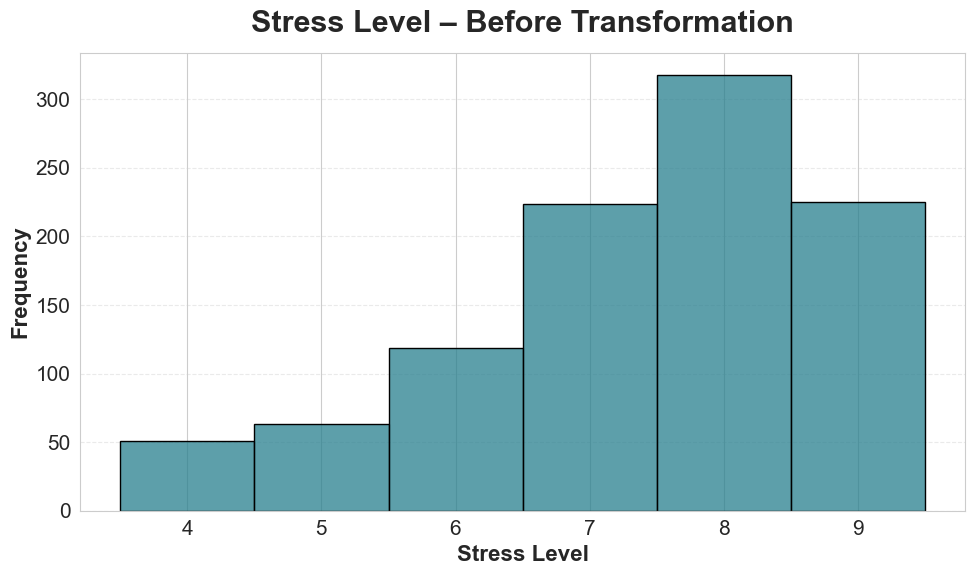

 Plot saved to: stress_level_graphs\Histogram_Stress_Level_After.png


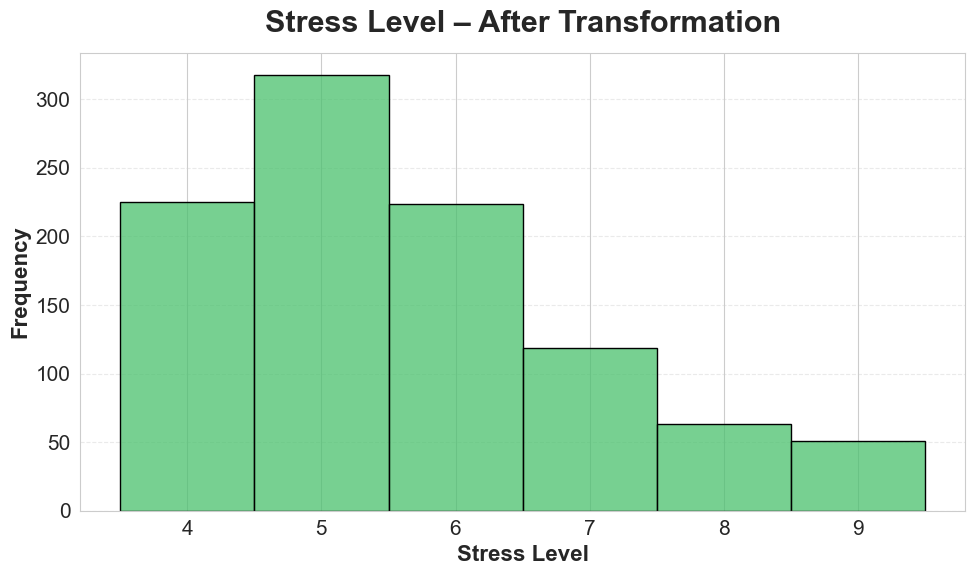

In [355]:
plot_stress_level_hist(X_test, X_sim_stress)

#### Combination of 2 Features Simulations

In [357]:
turnovers = {'Job Satisfaction': turnover_sim_job, 'EAP Access':turnover_sim_eap, 'Mental health Absences':turnover_sim_mental, 'Stress Level':turnover_sim_stress}

for keys, values in turnovers.items():
	print('Δ turnover relativo ao', keys,'simulado é:', round(values-turnover_base,4))

Δ turnover relativo ao Job Satisfaction simulado é: -0.134
Δ turnover relativo ao EAP Access simulado é: -0.001
Δ turnover relativo ao Mental health Absences simulado é: -0.008
Δ turnover relativo ao Stress Level simulado é: 0.001


##### Job Satisfaction + Others

In [369]:
Xdata_mod = {'Access to EAPs': X_sim_eap, 'Mental Health Absences': X_sim_mental, 'Stress Level': X_sim_stress, 'Burnout Frequency': X_sim_burnout}
X_sim_combined = X_sim_job.copy()

for keys, values in Xdata_mod.items():
	X_sim_combined[keys] = values[keys]
	y_pred_sim_combined = model4.predict(X_sim_combined)
	turnover_combined = np.mean(y_pred_sim_combined) 
	print(f"turnover relativo ao Job Satisfaction + {keys} simulado é: {turnover_combined:.3f}")
	print(f"Δ turnover relativo ao Job Satisfaction + {keys} simulado é: {turnover_combined-turnover_base:.3f}")


turnover relativo ao Job Satisfaction + Access to EAPs simulado é: 0.638
Δ turnover relativo ao Job Satisfaction + Access to EAPs simulado é: -0.133
turnover relativo ao Job Satisfaction + Mental Health Absences simulado é: 0.622
Δ turnover relativo ao Job Satisfaction + Mental Health Absences simulado é: -0.149
turnover relativo ao Job Satisfaction + Stress Level simulado é: 0.434
Δ turnover relativo ao Job Satisfaction + Stress Level simulado é: -0.337
turnover relativo ao Job Satisfaction + Burnout Frequency simulado é: 0.449
Δ turnover relativo ao Job Satisfaction + Burnout Frequency simulado é: -0.322


# Clustering

#### Reading dataset

In [371]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
#Load the data
df = pd.read_csv("C:/Users/35192/Desktop/AnaliseDadosSaude/PROJETO2ANALISE_DADOS_SAUDE/archive/Healthcare Workforce Mental Health Dataset.csv")
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Employee ID             5000 non-null   object
 1   Employee Type           5000 non-null   object
 2   Department              5000 non-null   object
 3   Workplace Factor        5000 non-null   object
 4   Stress Level            5000 non-null   int64 
 5   Burnout Frequency       5000 non-null   object
 6   Job Satisfaction        5000 non-null   int64 
 7   Access to EAPs          5000 non-null   object
 8   Mental Health Absences  5000 non-null   int64 
 9   Turnover Intention      5000 non-null   object
dtypes: int64(3), object(7)
memory usage: 390.8+ KB


,Employee ID,Employee Type,Department,Workplace Factor,Stress Level,Burnout Frequency,Job Satisfaction,Access to EAPs,Mental Health Absences,Turnover Intention
0,HCP-00001,Pediatric Nurse,Pediatrics,Heavy Workload,8,Often,2,Yes,6,No
1,HCP-00002,Laboratory Technician,Laboratory,Safety Concerns,8,Often,1,Yes,12,No
2,HCP-00003,Nursing Assistant,Assisted Living,Poor Work Environment,6,Occasionally,2,Yes,9,Yes
3,HCP-00004,Medical Assistant,Outpatient Services,Poor Work Environment,7,Never,4,No,11,No
4,HCP-00005,Registered Nurse,General Medicine,Work-Life Imbalance,8,Occasionally,2,Yes,7,No


### Principal Component Analysis (PCA)

#### Encoding variables

In [373]:
#Delete Employee ID
df = df.drop(labels='Employee ID', axis=1) 

df_target = df["Turnover Intention"]
df_target = df_target.replace({'Yes': 1, 'No': 0})
df_data = df.drop(labels = "Turnover Intention", axis=1)

EmpType = list(df_data['Employee Type'].unique())
Dep = list(df_data['Department'].unique())
WFac = list(df_data['Workplace Factor'].unique())
Burnout = list(df_data['Burnout Frequency'].unique())

#print(EmpType)
#print(Dep)
#print(WFac)
#print(Burnout)

columns_onehot = ['Employee Type', 'Department', 'Workplace Factor']
onehot = OneHotEncoder(sparse_output=False, drop='first')
encoded_1hot = onehot.fit_transform(df_data[columns_onehot])

#New dataframe with only 1hot encoded variables
encoded_1hot_df = pd.DataFrame(encoded_1hot, columns = onehot.get_feature_names_out(columns_onehot))
#encoded_1hot_df.head()

#Concatenate original and encoded dataframes while removing original columns to be onehot encoded
df_data = pd.concat([df_data.drop(labels = columns_onehot, axis=1), encoded_1hot_df], axis=1)
#df_data.info()


labelencoding = {}
for column in df_data.select_dtypes(include = object):
		LabelEnc = LabelEncoder()
		df_data[column] = LabelEnc.fit_transform(df_data[column])
		labelencoding[column] = LabelEnc

for column, LabelEnc in labelencoding.items():
		print(f"Column: {column}")
		print(f"{LabelEnc.classes_} -> {LabelEnc.transform(LabelEnc.classes_)}")



Column: Burnout Frequency
['Never' 'Occasionally' 'Often'] -> [0 1 2]
Column: Access to EAPs
['No' 'Yes'] -> [0 1]


C:\Users\35192\AppData\Local\Temp\ipykernel_13872\3324506338.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_target = df_target.replace({'Yes': 1, 'No': 0})


#### Scale Numerical Features

In [375]:
numerical =['Stress Level', 'Burnout Frequency', 'Job Satisfaction', 'Mental Health Absences']
df_data_scaled = df_data

for column in numerical:
	scaler = StandardScaler()
	#scalerminmax = MinMaxScaler()
	df_data_scaled[column] = scaler.fit_transform(df_data[[column]])
	#df_data_scaled[column] = scalerminmax.fit_transform(df_data_scaled[[column]])


df_data_scaled.head()

,Stress Level,Burnout Frequency,Job Satisfaction,Access to EAPs,Mental Health Absences,Employee Type_Healthcare Administrator,Employee Type_Laboratory Technician,Employee Type_Medical Assistant,Employee Type_Nursing Assistant,Employee Type_Pediatric Nurse,...,Department_Pediatrics,Department_Radiology,Department_Specialty Care,Workplace Factor_Emotional Demands,Workplace Factor_Heavy Workload,Workplace Factor_Job Insecurity,Workplace Factor_Poor Work Environment,Workplace Factor_Safety Concerns,Workplace Factor_Unclear Job Expectations,Workplace Factor_Work-Life Imbalance
0,0.477573,0.988742,-0.193379,1,-0.485072,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.477573,0.988742,-1.149752,1,1.599465,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,-0.943353,-0.378056,-0.193379,1,0.557197,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,-0.232890,-1.744855,1.719367,0,1.252042,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.477573,-0.378056,-0.193379,1,-0.137649,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


#### PCA Computation and Visualization

[0.32965333 0.15904757]


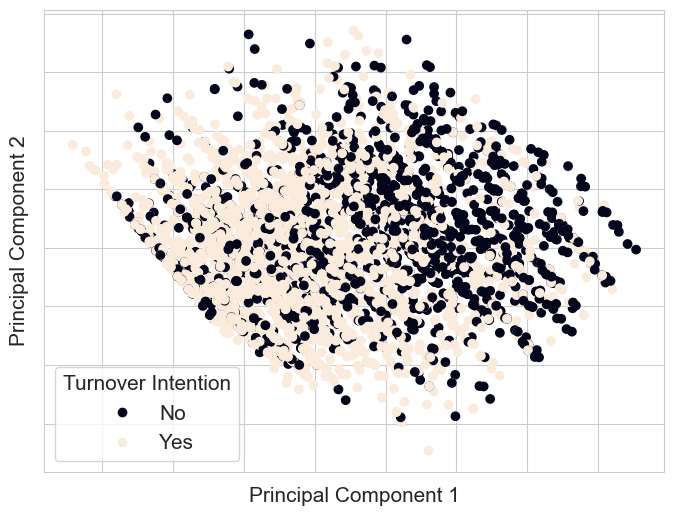

In [377]:
pca2d = PCA(n_components=2)
pca_output2d = pca2d.fit_transform(df_data_scaled)

#pca3d = PCA(n_components=3)
#pca_output3d = pca3d.fit_transform(df_data_scaled)

print(pca2d.explained_variance_ratio_)
#print(pca3d.explained_variance_ratio_)


labels = ['No', 'Yes']

#fig = plt.figure(figsize=(8,6))
#ax = fig.add_subplot(111, projection = '3d',elev=-150, azim=110)

#scatter = ax.scatter3D(
    #xs=pca_output3d[:,0],
    #ys=pca_output3d[:,1],
    #zs=pca_output3d[:,2],
    #c=df_target,
	#)
#ax.set_xlabel('PC1')
#ax.set_ylabel('PC2')
#ax.set_zlabel('PC3')
#handles,_ = scatter.legend_elements()
#ax.legend(handles, labels, title='Turnover Intention')
#ax.xaxis.set_ticklabels([])
#ax.yaxis.set_ticklabels([])
#ax.zaxis.set_ticklabels([])

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111)

scatter = ax.scatter(
    x=pca_output2d[:,0],
    y=pca_output2d[:,1],
    c=df_target,
    label = df_target	
	)

ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
handles,_ = scatter.legend_elements()
ax.legend(handles, labels, title='Turnover Intention')
ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])

plt.show()

## K-Means

#### Assessment of ideal number of clusters using Silhouette Score

C:\Users\35192\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\35192\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\35192\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\35192\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of

([<matplotlib.axis.XTick at 0x20eeb882420>,
 [Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6')])

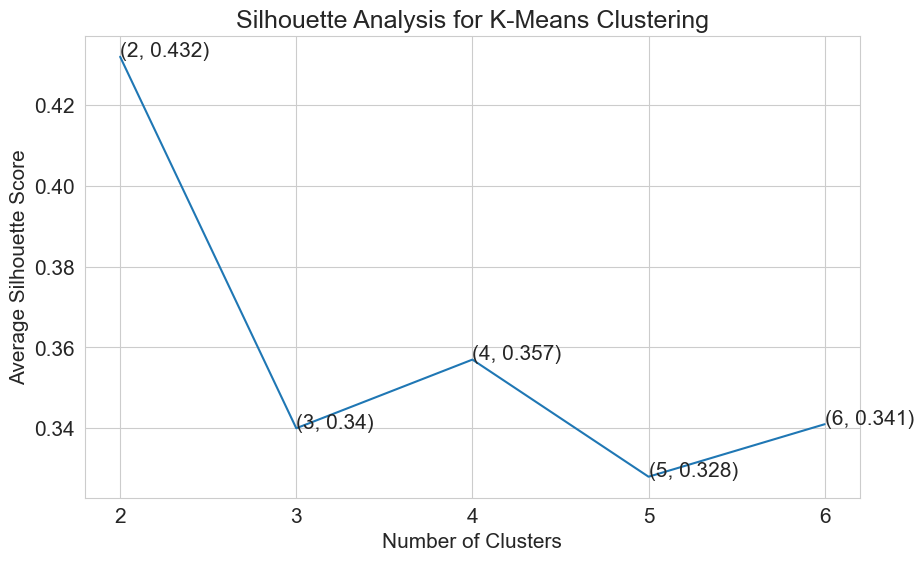

In [379]:
cluster_list = [2,3,4,5,6]
silhouette_list = []

for clusters in cluster_list:

	clusterer = KMeans(n_clusters=clusters)
	kmeans_labels = clusterer.fit_predict(pca_output2d)
	#kmeans_labels = clusterer.fit_predict(df_data_scaled)

	#Get average silhouette coefficent for each nº of clusters
	silhouette_avg = silhouette_score(pca_output2d, kmeans_labels)
	silhouette_list.append(silhouette_avg)	
	#silhouette_avg = silhouette_score(df_data_scaled, kmeans_labels)	
	#print("For nº of clusters =",clusters,",the average silhouette score is:", silhouette_avg)

	#Get silhouette score for each sample
	#silhouette_score_sample = silhouette_samples(pca_output2d, kmeans_labels)
	silhouette_score_sample = silhouette_samples(df_data_scaled, kmeans_labels)

silhouette_list = [round(x, 3) for x in silhouette_list]
plt.plot(cluster_list, silhouette_list)

for i_x, i_y in zip(cluster_list, silhouette_list):
	plt.text(i_x, i_y, '({}, {})'.format(i_x, i_y))

plt.xlabel('Number of Clusters')
plt.ylabel('Average Silhouette Score')
plt.title('Silhouette Analysis for K-Means Clustering')

plt.xticks(np.arange(2, 7, 1))

#### Silhouette analysis for KMeans clustering with ideal number of clusters

C:\Users\35192\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Text(0, 0.5, 'Feature space for the 2nd feature')

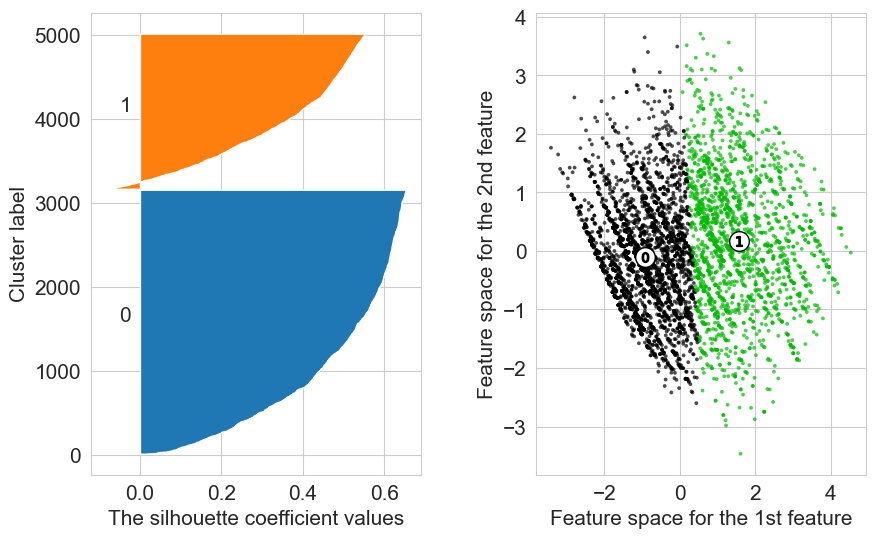

In [381]:
max_cluster = cluster_list[silhouette_list.index(max(silhouette_list))]

clusterer = KMeans(n_clusters=max_cluster)
#kmeans_labels = clusterer.fit_predict(df_data_scaled)
#silhouette_vals = silhouette_samples(df_data_scaled, kmeans_labels)
kmeans_labels = clusterer.fit_predict(pca_output2d)
silhouette_score_sample = silhouette_samples(pca_output2d, kmeans_labels)

fig, (ax1, ax2) = plt.subplots(1, 2)
plt.subplots_adjust(wspace=0.35)
ylower = 10
for i in range(max_cluster):
	ith_cluster_silhouette_values = silhouette_score_sample[kmeans_labels == i]

	ith_cluster_silhouette_values.sort()
	size_cluster_i = ith_cluster_silhouette_values.shape[0]

	yupper = ylower + size_cluster_i

	ax1.fill_betweenx(
			np.arange(ylower, yupper),
			0,
			ith_cluster_silhouette_values
	)

	
	#Label the silhouette plots with their cluster numbers at the middle
	ax1.text(-0.05, ylower + 0.5 * size_cluster_i, str(i))

	#Compute the new y_lower for next plot
	ylower = yupper + 10  # 10 for the 0 samples

ax1.set_xlabel("The silhouette coefficient values")
ax1.set_ylabel("Cluster label")

#2nd Plot showing the actual clusters formed
colors = cm.nipy_spectral(kmeans_labels.astype(float) / max_cluster)
ax2.scatter(
		pca_output2d[:, 0], 
		pca_output2d[:, 1], 
		marker=".", 
		s=30, lw=0, alpha=0.7, c=colors, edgecolor="k"
)

#Labeling the clusters
centers = clusterer.cluster_centers_
#Draw white circles at cluster centers
ax2.scatter(
		centers[:, 0],
		centers[:, 1],
		marker="o",
		c="white",
		alpha=1,
		s=200,
		edgecolor="k",
)

for i, c in enumerate(centers):
		ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")

ax2.set_xlabel("Feature space for the 1st feature")
ax2.set_ylabel("Feature space for the 2nd feature")